In [1]:
#use the corv_wd_models.yml environment

import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
from scipy.stats import norm
from scipy import stats
from scipy.optimize import curve_fit
from tqdm import tqdm
import scipy as sc
from astroquery.gaia import Gaia

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Suppress SettingWithCopyWarnings
pd.options.mode.chained_assignment = None  # default='warn'

#for multiprocessing
from joblib import Parallel, delayed
import time

#to import SDSS-V data
import fsspec
import requests
import aiohttp
from astropy.io import fits

#manually import corv, make sure all the .py files are in the corv_picklable folder
#corv_nicole is a version of corv_montreal where the paths to the models are hard-coded instead of given 
#by the user. User input is a non-picklable function and messes up the multiprocessing
import sys
import os
sys.path.append('../Software')
from corv_nicole.spectral_resampling import spectres
from corv_nicole.utils import get_medsn
from corv_nicole.models import make_montreal_da_model
from corv_nicole.fit import fit_corv
from corv_nicole.utils import lineplot


In [2]:
#input SDSS-V username and password
file=open('SDSSVlogin.txt')
content = file.readlines()
username=content[0][:len(content[0])-1] #remove the \n
password=content[1]

# This notebook measures the DA WD RVs using corv using the IPL-3 v6_1_3 reductions for SDSS-V WDs and the downloaded spectra for eSDSS WDs

**LATEST link to data:**

https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra

# Import the datasets

In [3]:
# read in the short tables, either from the backup file or from the latest version of the table
backup=False

if backup==True:
    #read in all object id lists
    SDSSV_num_id_sets=np.genfromtxt('csv/SDSSV_num_id_sets.txt',dtype=int)
    id_SDSSV_dict={}
    for i in tqdm(range(SDSSV_num_id_sets)):
        id_SDSSV_dict['set_'+str(i)]=np.genfromtxt('csv/SDSSV_short_sets/SDSSV_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    SDSSV_dict={}
    size=0
    for i in tqdm(range(SDSSV_num_id_sets)):
        SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'_nb01.csv')
        size=size+len(SDSSV_dict['set_'+str(i)])
        
    #read in all object id lists
    eSDSS_num_id_sets=np.genfromtxt('csv/eSDSS_num_id_sets.txt',dtype=int)
    id_eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        id_eSDSS_dict['set_'+str(i)]=np.genfromtxt('csv/eSDSS_short_sets/eSDSS_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'_nb02.csv')
        
else:
    #read in all object id lists
    SDSSV_num_id_sets=np.genfromtxt('csv/SDSSV_num_id_sets.txt',dtype=int)
    id_SDSSV_dict={}
    for i in tqdm(range(SDSSV_num_id_sets)):
        id_SDSSV_dict['set_'+str(i)]=np.genfromtxt('csv/SDSSV_short_sets/SDSSV_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    SDSSV_dict={}
    size=0
    for i in tqdm(range(SDSSV_num_id_sets)):
        SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv')
        size=size+len(SDSSV_dict['set_'+str(i)])
        
     #read in all object id lists
    eSDSS_num_id_sets=np.genfromtxt('csv/eSDSS_num_id_sets.txt',dtype=int)
    id_eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        id_eSDSS_dict['set_'+str(i)]=np.genfromtxt('csv/eSDSS_short_sets/eSDSS_obj_ids_'+str(i)+'.txt',dtype=str)
    #read in all data tables
    eSDSS_dict={}
    for i in tqdm(range(eSDSS_num_id_sets)):
        eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv')



100%|██████████████████████████████████████████| 49/49 [00:00<00:00, 185.97it/s]


In [4]:
#read in the full tables, either from the backup file or from the latest version of the table
backup=False
if backup==True:
    SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df_nb01.csv')
    eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df_nb02.csv')
else:
    SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df.csv')
    eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df.csv')

# Make Coadds

In [5]:
def plot_spectrum(spec, SDSSType, ylim='default'):
    if SDSSType=='SDSSV':
        #spec is a fits file containing the SDSS spectra for the object in spec data model format
        #the coadded spectrum data is HDU1
        #spec = SDSS.get_spectra_async(plate, fiberID, mjd)[0].get_fits()
        
        wl = 10**spec[1].data['loglam'] #wavelength in angstroms
        fl = spec[1].data['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = spec[1].data['ivar'] #inverse variance of the flux, the error on the flux is ivar^-0.5
        
    if SDSSType=='eSDSS':
        #spec is early SDSS data filename
        npzfile = np.load('csv/eSDSS_spectra/'+spec+'.npz')
        wl = npzfile['wavl'] #wavelength in angstroms
        fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = npzfile['ivar'] #inverse variance of the flux, the error on the flux is ivar^-0.5
        
    if SDSSType=='coadd':
        #spec is array of wl,fl,ivar
        wl=spec[0]
        fl=spec[1]
        ivar=spec[2]
    
    balmer_lines=[6564.61, 4862.68, 4341.68, 4102.89, 3971.20, 3890.12, 3835.5, 3799.5]
    #hydrogen emission lines in angstroms for vacuum
    
    fig, ax=plt.subplots(1,1,figsize=(12,6))
    plt.style.use('stefan.mplstyle')
    ax.plot(wl, fl)
    
    if ylim=='default':
        min_, max_ = plt.ylim()
    else:
        min_=ylim[0]
        max_=ylim[1]
    ax.set_ylim((min_,max_))
    ax.vlines(balmer_lines, min_, max_, colors = 'black', linestyle = 'dashed', alpha = 0.5)
    ax.set_ylabel(r'Flux [$10^{-17} \mathrm{ergs/s/cm^2/\AA}$]')
    ax.set_xlabel(r'Wavelength [$\mathrm{\AA}$]')
    plt.title('WD Spectrum')
    
    return(wl,fl,ivar,fig)

In [6]:
def make_coadd(wls,fls,ivars):
    #this is a version of Vedant's make_coadd using ivar_mean method from corv
    #the method is the same, the code is just modified for my preferred data formatting
    
    #wls is array of wavelengths, each entry corresponding to one spectrum to coadd
    #fls is array of fluxes
    #ivars is array of ivars

    #number of spectra
    nexp = len(wls)
    
    #number of datapoints in each spectrum
    nwl=len(wls[0])
    
    #make a grid of log wavelengths to use in resampling the spectra
    #this is to make sure we always have a consistent wl grid
    loglam0 = 3.55230
    step = 0.0001
    loglamgrid = np.linspace(loglam0, loglam0 + nwl * step, nwl)
    lamgrid = 10**loglamgrid
    
    #resample the spectra
    resamp_fls = np.zeros((nexp, nwl))
    resamp_sigmas = np.zeros((nexp, nwl))
    for i in range(nexp):
        logwl=np.log10(wls[i])
        fl=fls[i]
        ivar=ivars[i]
        with np.errstate(divide='ignore'):
            fl_i, sigma_i = spectres(loglamgrid, logwl, fl, np.reciprocal(np.sqrt(ivar)),verbose=False)
        resamp_fls[i, :] = fl_i
        resamp_sigmas[i, :] = sigma_i
    
    #combine the resampled spectra
    fl = np.zeros(nwl)
    sigma = np.zeros(nwl)
    mask = np.ones(nwl).astype(bool)
    for px in range(nwl): 
        fl_px = resamp_fls[:, px]
        sigma_px = resamp_sigmas[:, px]
        goodmask = np.isfinite(sigma_px)
        goodmask *= (fl_px > 0)
        ngood = np.sum(goodmask)
        if ngood > 0:
            # using method == 'ivar_mean' from Vedant's code
            fl[px] = np.average(fl_px[goodmask], weights = 1/sigma_px[goodmask]**2)
            sigma[px] = np.sqrt(1 / np.sum(1/sigma_px[goodmask]**2))
        else:
            mask[px] = False # where mask == False, there is zero usable data
            fl[px] = np.nan
            sigma[px] = np.inf
            
    ivar = 1 / sigma**2
    ivar[~mask] = 0.0

    return lamgrid, fl, ivar

In [9]:
def make_coadd_SDSSV(obj_id,table,verbose=False,save=True,plot=False):
    try:
        os.makedirs('csv/SDSSV_coadds')
    except:
        pass
    
    if verbose==True:
        print(obj_id)
    #this function collects the SDSSV data and makes the coadd
    obj_id_int=int(obj_id)
    wd_table=table.query('gaia_dr3_source_id==@obj_id_int')
    #reset the indices
    indices=np.arange(0,len(wd_table))
    wd_table.set_index(indices,inplace=True)
    
    #number of spectra to coadd
    nexp=len(wd_table)

    if nexp>1:
        if verbose==True:
            print('coadding spectra')
        #get the data for the spectra
        wls=[]
        fls=[]
        ivars=[]
        for ind in range(len(wd_table)):
            # Open the SDSS-V fits file
            fieldid=str(wd_table['fieldid'][ind])
            if len(fieldid)<6:
                fieldid='0'+fieldid
            mjd=str(wd_table['mjd'][ind])
            catalogid=str(wd_table['catalogid'][ind])
            fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
            #USE v6_1_3 THIS IS THE LATEST VERSION OF THE DR19 REDUCTIONS
            url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
           
            with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
                # Get pertinent spectrum data    
                wl = np.array(10**spec[1].data['loglam'])
                fl = np.array(spec[1].data['flux'])
                ivar = np.array(spec[1].data['ivar'])
                wls.append(wl)
                fls.append(fl)
                ivars.append(ivar)
                if plot==True:
                    print('Individual Spectrum')
                    #plot the spectrum
                    ymin=-10
                    ymax=max(fl[500:])
                    output=plot_spectrum(spec,SDSSType='SDSSV',ylim=(ymin,ymax))
                    plt.show()

        #make coadd, get coadd snr
        coadd_wl,coadd_fl,coadd_ivar=make_coadd(wls,fls,ivars)
        #trim the coadded arrays to remove any nan values
        nanmask_wl=np.isnan(coadd_wl)
        coadd_wl=coadd_wl[~nanmask_wl]
        coadd_fl=coadd_fl[~nanmask_wl]
        coadd_ivar=coadd_ivar[~nanmask_wl]
        nan_check=np.count_nonzero(np.isnan(coadd_fl))+np.count_nonzero(np.isnan(coadd_ivar))
        if nan_check>0:
            nanmask_fl=np.isnan(coadd_fl)
            coadd_wl=coadd_wl[~nanmask_fl]
            coadd_fl=coadd_fl[~nanmask_fl]
            coadd_ivar=coadd_ivar[~nanmask_fl]
            nan_check=np.count_nonzero(np.isnan(coadd_ivar))
            if nan_check>0:
                nanmask_ivar=np.isnan(coadd_ivar)
                coadd_wl=coadd_wl[~nanmask_ivar]
                coadd_fl=coadd_fl[~nanmask_ivar]
                coadd_ivar=coadd_ivar[~nanmask_ivar]
        #get coadd snr using median snr method
        coadd_snr,coadd_snr2=get_medsn(coadd_wl,coadd_fl,coadd_ivar) 
        if save==True:
            #write the data in a txt file
            np.savez('csv/SDSSV_coadds/'+str(obj_id),flux=coadd_fl,wavl=coadd_wl,ivar=coadd_ivar,snr=coadd_snr)
            
        if plot==True:
            print('Coadded Spectrum, SNR='+str(coadd_snr))
            #plot the spectrum
            ymin=-10
            ymax=max(fl[500:])
            spec=[coadd_wl,coadd_fl,coadd_ivar]
            output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
            plt.show()
    else:
        if verbose==True:
            print("Only 1 spectrum for this object, not coadding")
            

In [10]:
def make_coadd_eSDSS(obj_id,table,verbose=False,save=True,plot=False):
    try:
        os.makedirs('csv/eSDSS_coadds')
    except:
        pass
    
    if verbose==True:
        print(obj_id)
    #this function collects the eSDSS data and makes the coadd
    obj_id_int=int(obj_id)
    wd_table=table.query('gaia_dr3_source_id==@obj_id_int')
    #reset the indices
    indices=np.arange(0,len(wd_table))
    wd_table.set_index(indices,inplace=True)
    
    #number of spectra to coadd
    nexp=len(wd_table)

    if nexp>1:
        if verbose==True:
            print('coadding spectra')
        #get the data for the spectra
        wls=[]
        fls=[]
        ivars=[]
        for ind in range(len(wd_table)):
            # Open the saved eSDSS spectrum
            plate=wd_table['plate'].loc[ind]
            mjd=wd_table['mjd'].loc[ind]
            fiber=wd_table['fiber'].loc[ind]   
            filename=str(wd_table['pmf'].loc[ind])
            #Get pertinent spectrum data 
            npzfile = np.load('csv/eSDSS_spectra/'+filename+'.npz')
            wl = npzfile['wavl'] #wavelength in angstroms
            fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
            ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
            wls.append(wl)
            fls.append(fl)
            ivars.append(ivar)
            if plot==True:
                print('Individual Spectrum')
                #plot the spectrum
                ymin=-10
                ymax=max(fl[500:])
                output=plot_spectrum(filename,SDSSType='eSDSS',ylim=(ymin,ymax))
                plt.show()
        #make coadd, get coadd snr
        coadd_wl,coadd_fl,coadd_ivar=make_coadd(wls,fls,ivars)
        #trim the coadded arrays to remove any nan values
        nanmask_wl=np.isnan(coadd_wl)
        coadd_wl=coadd_wl[~nanmask_wl]
        coadd_fl=coadd_fl[~nanmask_wl]
        coadd_ivar=coadd_ivar[~nanmask_wl]
        nan_check=np.count_nonzero(np.isnan(coadd_fl))+np.count_nonzero(np.isnan(coadd_ivar))
        if nan_check>0:
            nanmask_fl=np.isnan(coadd_fl)
            coadd_wl=coadd_wl[~nanmask_fl]
            coadd_fl=coadd_fl[~nanmask_fl]
            coadd_ivar=coadd_ivar[~nanmask_fl]
            nan_check=np.count_nonzero(np.isnan(coadd_ivar))
            if nan_check>0:
                nanmask_ivar=np.isnan(coadd_ivar)
                coadd_wl=coadd_wl[~nanmask_ivar]
                coadd_fl=coadd_fl[~nanmask_ivar]
                coadd_ivar=coadd_ivar[~nanmask_ivar]
        #get coadd snr using median snr method
        coadd_snr,coadd_snr2=get_medsn(coadd_wl,coadd_fl,coadd_ivar) 
        if save==True:
            #write the data in a txt file
            np.savez('csv/eSDSS_coadds/'+str(obj_id),flux=coadd_fl,wavl=coadd_wl,ivar=coadd_ivar,snr=coadd_snr)
            
        if plot==True:
            print('Coadded Spectrum, SNR='+str(coadd_snr))
            #plot the spectrum
            ymin=-10
            ymax=max(fl[500:])
            spec=[coadd_wl,coadd_fl,coadd_ivar]
            output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
            plt.show()
    else:
        if verbose==True:
            print("Only 1 spectrum for this object, not coadding")
            

### Show some coadds

In [ ]:
i=0
obj_ids=id_SDSSV_dict['set_'+str(i)]
table=SDSSV_dict['set_'+str(i)]

for obj_id in tqdm(obj_ids[:3]):
    make_coadd_SDSSV(obj_id,table,verbose=True,save=True,plot=True)


In [ ]:
i=0
obj_ids=id_eSDSS_dict['set_'+str(i)]
table=eSDSS_dict['set_'+str(i)]

for obj_id in tqdm(obj_ids[5:6]):
    print(obj_id)
    make_coadd_eSDSS(obj_id,table,verbose=True,save=True,plot=True)


### Make all coadds

In [11]:
def parallelprocess_make_coadd_SDSSV(i):
    obj_ids=id_SDSSV_dict['set_'+str(i)]
    table=SDSSV_dict['set_'+str(i)]
    for obj_id in obj_ids:
        make_coadd_SDSSV(obj_id,table,verbose=False,save=True,plot=False)

In [12]:
def parallelprocess_make_coadd_eSDSS(i):
    obj_ids=id_eSDSS_dict['set_'+str(i)]
    table=eSDSS_dict['set_'+str(i)]
    for obj_id in obj_ids:
        make_coadd_eSDSS(obj_id,table,verbose=False,save=True,plot=False)

In [ ]:
#run for each set of SDSSV ids
print(SDSSV_num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_make_coadd_SDSSV)(i) for i in range(SDSSV_num_id_sets))

In [ ]:
#run for each set of eSDSS ids
print(eSDSS_num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_make_coadd_eSDSS)(i) for i in range(eSDSS_num_id_sets))

# Define functions to fit the WD RVs using corv with Montreal Models
From the corv RV analysis, Montreal models perform better at low SNR than Voigt models and are comparable to the Koester models.

For each SDSSV or eSDSS WD (keep the two sets separate):
- fit the RV for each individual observation
- fit the RV for the coadded spectrum
- take the weighted average RV for each object but only for spectra passing the SNR cut (SNR>10)


In [15]:
#default parameters
default_nvoigt=1
default_names = ['a','b','g','d']
default_centers= dict(a = 6564.61, b = 4862.68, g = 4341.68, d = 4102.89, e = 3971.20, z = 3890.12, n = 3835.5,
                      t = 3799.5)
default_windows =dict(a = 100, b = 100, g = 85, d = 70, e = 30, z = 25, n = 15, t = 10)
default_edges = dict(a = 25, b = 25, g = 20, d = 20, e = 5, z = 5, n = 5, t = 4)

In [16]:
def fit_montreal_SDSSV(obj_id,table,names=default_names, centres=default_centers,windows=default_windows,
                edges=default_edges,plot=False):
    #this function fits a montreal model to each WD coadd and all individual spectra
    
    obj_id_int=int(obj_id)
    wd_table=table.query('gaia_dr3_source_id==@obj_id_int')
    #reset the indices
    indices=np.arange(0,len(wd_table))
    wd_table.set_index(indices,inplace=True)
    
    #make a corv model with Montreal templates
    corvmodel = make_montreal_da_model(centres = default_centers, windows = default_windows,
                                               edges = default_edges, names = default_names)
    
    #get the data for the spectra
    individual_rvs=[]
    e_individual_rvs=[]
    individual_teffs=[] 
    individual_loggs=[]
    individual_snrs=[]
    for ind in range(len(wd_table)):
        individual_snrs.append(wd_table['snr'].loc[ind])
        # Open the SDSS-V fits file
        fieldid=str(wd_table['fieldid'][ind])
        if len(fieldid)<6:
            fieldid='0'+fieldid
        mjd=str(wd_table['mjd'][ind])
        catalogid=str(wd_table['catalogid'][ind])
        fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
        url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
       
        with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
            # Get pertinent spectrum data    
            wl = np.array(10**spec[1].data['loglam'])
            fl = np.array(spec[1].data['flux'])
            ivar = np.array(spec[1].data['ivar'])
            if plot==True:
                print('Individual Spectrum')
                #plot the spectrum
                ymin=-10
                ymax=max(fl[500:])
                output=plot_spectrum(spec,SDSSType='SDSSV',ylim=(ymin,ymax))
                plt.show()
            try:
                #fit the corv model to the individual spectra
                rv,e_rv,redchi,param_res=fit_corv(wl, fl, ivar, corvmodel, iter_teff=True)
                individual_rvs.append(rv)
                e_individual_rvs.append(e_rv)
                individual_teffs.append(param_res.params['teff'].value) 
                individual_loggs.append(param_res.params['logg'].value)
                if plot==True:
                    print('Individual Spectrum Fit')
                    #plot the fit
                    fit_fig=lineplot(wl, fl, ivar, corvmodel, param_res.params, printparams = False, gap = 0.3, figsize = (6, 5))
                    plt.style.use('stefan.mplstyle')
                    plt.show()
                    print('RV='+str(rv)+' +/- '+str(e_rv))
            except:
                print('fit failed')
                individual_rvs.append(np.nan)
                e_individual_rvs.append(np.nan)
                individual_teffs.append(np.nan)
                individual_loggs.append(np.nan)
                
    #if there is more than 1 spectrum associated with the object, load the coadd data and fit that too
    nexp=len(wd_table)
    if nexp>1:
        #import data
        npzfile = np.load('csv/SDSSV_coadds/'+str(obj_id)+'.npz')
        coadd_wl = npzfile['wavl'] #wavelength in angstroms
        coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        coadd_snr = npzfile['snr']
        if plot==True:
            print('Coadded Spectrum, SNR='+str(coadd_snr))
            #plot the spectrum
            ymin=-10
            ymax=max(coadd_fl[500:])
            spec=[coadd_wl,coadd_fl,coadd_ivar]
            output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
            plt.show()
        
        try:
            #fit the corv model to the coadded spectra
            coadd_rv,e_coadd_rv,redchi,param_res=fit_corv(coadd_wl, coadd_fl, coadd_ivar, corvmodel, iter_teff=True)
            coadd_teff=param_res.params['teff'].value
            coadd_logg=param_res.params['logg'].value
            if plot==True:
                print('Coadded Spectrum Fit')
                #plot the fit
                fit_fig=lineplot(coadd_wl, coadd_fl, coadd_ivar, corvmodel, param_res.params, printparams = False, gap = 0.3, figsize = (6, 5))
                plt.style.use('stefan.mplstyle')
                plt.show()
                print('RV='+str(coadd_rv)+' +/- '+str(e_coadd_rv))
        except:
            print('coadd fit failed')
            coadd_rv=np.nan
            e_coadd_rv=np.nan 
            coadd_teff=np.nan
            coadd_logg=np.nan
    #if there aren't multiple spectra to coadd, save the individual spectrum params
    else:
        coadd_rv=individual_rvs[0]
        e_coadd_rv=e_individual_rvs[0]
        coadd_snr=individual_snrs[0]
        coadd_teff=individual_teffs[0]
        coadd_logg=individual_loggs[0]
        
    return(individual_rvs,e_individual_rvs,individual_teffs,individual_loggs,coadd_rv,e_coadd_rv,coadd_teff,coadd_logg,coadd_snr,nexp)
        

In [17]:
def fit_montreal_eSDSS(obj_id,table,names=default_names, centres=default_centers,windows=default_windows,
                edges=default_edges,plot=False):
    #this function fits a montreal model to each eSDSS spectrum of a WD
    obj_id_int=int(obj_id)
    wd_table=table.query('gaia_dr3_source_id==@obj_id_int')
    #reset the indices
    indices=np.arange(0,len(wd_table))
    wd_table.set_index(indices,inplace=True)
    
    #make a corv model with Montreal templates
    corvmodel = make_montreal_da_model(centres = default_centers, windows = default_windows,
                                               edges = default_edges, names = default_names)
    individual_rvs=[]
    e_individual_rvs=[]
    individual_teffs=[] 
    individual_loggs=[]
    individual_snrs=[]
    
    for ind in range(len(wd_table)):
        individual_snrs.append(wd_table['snr'].loc[ind])
        plate=wd_table['plate'].loc[ind]
        mjd=wd_table['mjd'].loc[ind]
        fiber=wd_table['fiber'].loc[ind]   
        filename=str(wd_table['pmf'].loc[ind])
        #Get pertinent spectrum data 
        npzfile = np.load('csv/eSDSS_spectra/'+filename+'.npz')
        wl = npzfile['wavl'] #wavelength in angstroms
        fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        try:
            #fit the corv model 
            rv,e_rv,redchi,param_res=fit_corv(wl, fl, ivar, corvmodel, iter_teff=True)
            individual_rvs.append(rv)
            e_individual_rvs.append(e_rv)
            individual_teffs.append(param_res.params['teff'].value) 
            individual_loggs.append(param_res.params['logg'].value)
        
            if plot==True:
                #plot the spectrum
                ymin=-10
                ymax=max(fl[500:])
                (wl_array,flux_array,ivar_array,spec_fig)=plot_spectrum(filename,'eSDSS',ylim=(ymin,ymax))
                plt.show()
        
                #plot the fit
                fit_fig=lineplot(wl, fl, ivar, corvmodel, param_res.params, printparams = False, gap = 0.3, figsize = (6, 5))
                plt.style.use('stefan.mplstyle')
                plt.show()
                print('RV='+str(rv)+' +/- '+str(e_rv))
        except:
            print('fit failed')
            individual_rvs.append(np.nan)
            e_individual_rvs.append(np.nan)
            individual_teffs.append(np.nan)
            individual_loggs.append(np.nan)
            
    #if there is more than 1 spectrum associated with the object, load the coadd data and fit that too
    nexp=len(wd_table)
    if nexp>1:
        #import data
        npzfile = np.load('csv/eSDSS_coadds/'+str(obj_id)+'.npz')
        coadd_wl = npzfile['wavl'] #wavelength in angstroms
        coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
        coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
        coadd_snr = npzfile['snr']
        if plot==True:
            print('Coadded Spectrum, SNR='+str(coadd_snr))
            #plot the spectrum
            ymin=-10
            ymax=max(coadd_fl[500:])
            spec=[coadd_wl,coadd_fl,coadd_ivar]
            output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
            plt.show()
        
        try:
            #fit the corv model to the coadded spectra
            coadd_rv,e_coadd_rv,redchi,param_res=fit_corv(coadd_wl, coadd_fl, coadd_ivar, corvmodel, iter_teff=True)
            coadd_teff=param_res.params['teff'].value
            coadd_logg=param_res.params['logg'].value
            if plot==True:
                print('Coadded Spectrum Fit')
                #plot the fit
                fit_fig=lineplot(coadd_wl, coadd_fl, coadd_ivar, corvmodel, param_res.params, printparams = False, gap = 0.3, figsize = (6, 5))
                plt.style.use('stefan.mplstyle')
                plt.show()
                print('RV='+str(coadd_rv)+' +/- '+str(e_coadd_rv))
        except:
            print('coadd fit failed')
            coadd_rv=np.nan
            e_coadd_rv=np.nan 
            coadd_teff=np.nan
            coadd_logg=np.nan
    #if there aren't multiple spectra to coadd, save the individual spectrum params
    else:
        coadd_rv=individual_rvs[0]
        e_coadd_rv=e_individual_rvs[0]
        coadd_snr=individual_snrs[0]
        coadd_teff=individual_teffs[0]
        coadd_logg=individual_loggs[0]
        
    return(individual_rvs,e_individual_rvs,individual_teffs,individual_loggs,coadd_rv,e_coadd_rv,coadd_teff,coadd_logg,coadd_snr,nexp)


# Fit the RVs and save the results

### Show some fits

In [ ]:
i=0
obj_ids=id_SDSSV_dict['set_'+str(i)][2:3].astype(int)
table=SDSSV_dict['set_'+str(i)][SDSSV_dict['set_'+str(i)]['gaia_dr3_source_id'].isin(obj_ids)]
#reset the indices
indices=np.arange(0,len(table))
table.set_index(indices,inplace=True)

rv_corv_ind=np.array([])
e_rv_corv_ind=np.array([])
teff_corv_ind=np.array([])
logg_corv_ind=np.array([])
rv_corv_coadd=np.array([])
e_rv_corv_coadd=np.array([])
teff_corv_coadd=np.array([])
logg_corv_coadd=np.array([])
snr_coadd=np.array([])
nexp_coadd=np.array([])
for obj_id in tqdm(obj_ids):
    individual_rvs,e_individual_rvs,individual_teffs,individual_loggs,coadd_rv,e_coadd_rv,coadd_teff,coadd_logg,coadd_snr,nexp=fit_montreal_SDSSV(obj_id,table,plot=True)
    rv_corv_ind=np.append(rv_corv_ind,individual_rvs)
    e_rv_corv_ind=np.append(e_rv_corv_ind,e_individual_rvs)
    teff_corv_ind=np.append(teff_corv_ind,individual_teffs)
    logg_corv_ind=np.append(logg_corv_ind,individual_loggs)
    rv_corv_coadd=np.append(rv_corv_coadd,np.full(len(individual_rvs),coadd_rv))
    teff_corv_coadd=np.append(teff_corv_coadd,np.full(len(individual_teffs),coadd_teff))
    logg_corv_coadd=np.append(logg_corv_coadd,np.full(len(individual_loggs),coadd_logg))
    e_rv_corv_coadd=np.append(e_rv_corv_coadd,np.full(len(individual_rvs),e_coadd_rv))
    snr_coadd=np.append(snr_coadd,np.full(len(individual_rvs),coadd_snr))
    nexp_coadd=np.append(nexp_coadd,np.full(len(individual_rvs),nexp))

table['rv_corv_ind']=rv_corv_ind.flatten()
table['e_rv_corv_ind']=e_rv_corv_ind.flatten()
table['teff_corv_ind']=teff_corv_ind.flatten()
table['logg_corv_ind']=logg_corv_ind.flatten()
table['rv_corv_coadd']=rv_corv_coadd.flatten()
table['e_rv_corv_coadd']=e_rv_corv_coadd.flatten()
table['teff_corv_coadd']=teff_corv_coadd.flatten()
table['logg_corv_coadd']=logg_corv_coadd.flatten()
table['snr_coadd']=snr_coadd.flatten()
table['nspec_coadd']=nexp_coadd.flatten()
display(table)

In [ ]:
i=0
obj_ids=id_eSDSS_dict['set_'+str(i)][5:6].astype(int)
table=eSDSS_dict['set_'+str(i)][eSDSS_dict['set_'+str(i)]['gaia_dr3_source_id'].isin(obj_ids)]
#reset the indices
indices=np.arange(0,len(table))
table.set_index(indices,inplace=True)

rv_corv_ind=np.array([])
e_rv_corv_ind=np.array([])
teff_corv_ind=np.array([])
logg_corv_ind=np.array([])
rv_corv_coadd=np.array([])
e_rv_corv_coadd=np.array([])
teff_corv_coadd=np.array([])
logg_corv_coadd=np.array([])
snr_coadd=np.array([])
nexp_coadd=np.array([])
for obj_id in tqdm(obj_ids):
    individual_rvs,e_individual_rvs,individual_teffs,individual_loggs,coadd_rv,e_coadd_rv,coadd_teff,coadd_logg,coadd_snr,nexp=fit_montreal_eSDSS(obj_id,table,plot=True)
    rv_corv_ind=np.append(rv_corv_ind,individual_rvs)
    e_rv_corv_ind=np.append(e_rv_corv_ind,e_individual_rvs)
    teff_corv_ind=np.append(teff_corv_ind,individual_teffs)
    logg_corv_ind=np.append(logg_corv_ind,individual_loggs)
    rv_corv_coadd=np.append(rv_corv_coadd,np.full(len(individual_rvs),coadd_rv))
    teff_corv_coadd=np.append(teff_corv_coadd,np.full(len(individual_teffs),coadd_teff))
    logg_corv_coadd=np.append(logg_corv_coadd,np.full(len(individual_loggs),coadd_logg))
    e_rv_corv_coadd=np.append(e_rv_corv_coadd,np.full(len(individual_rvs),e_coadd_rv))
    snr_coadd=np.append(snr_coadd,np.full(len(individual_rvs),coadd_snr))
    nexp_coadd=np.append(nexp_coadd,np.full(len(individual_rvs),nexp))

table['rv_corv_ind']=rv_corv_ind.flatten()
table['e_rv_corv_ind']=e_rv_corv_ind.flatten()
table['teff_corv_ind']=teff_corv_ind.flatten()
table['logg_corv_ind']=logg_corv_ind.flatten()
table['rv_corv_coadd']=rv_corv_coadd.flatten()
table['e_rv_corv_coadd']=e_rv_corv_coadd.flatten()
table['teff_corv_coadd']=teff_corv_coadd.flatten()
table['logg_corv_coadd']=logg_corv_coadd.flatten()
table['snr_coadd']=snr_coadd.flatten()
table['nspec_coadd']=nexp_coadd.flatten()
display(table)

### Show SDSS spectra with SNR~5, 10, and 20

In [ ]:
#find spectra with desired snr
snrnum=20

for i in tqdm(range(SDSSV_num_id_sets)):
    num_id=i #which table
    tmp=SDSSV_dict['set_'+str(num_id)].query('@snrnum-0.04<snr<@snrnum+0.04')[['gaia_dr3_source_id','fieldid','mjd','catalogid','snr']]
    #reset the indices
    indices=np.arange(0,len(tmp))
    tmp.set_index(indices,inplace=True)
    
    #plot each spectrum
    for ind in range(len(tmp)):
        print('num_id=',num_id)
        print('obj_id=',tmp['gaia_dr3_source_id'][ind])
        print('mjd=',tmp['mjd'][ind])
        # Open the SDSS-V fits file
        fieldid=str(tmp['fieldid'][ind])
        if len(fieldid)<6:
            fieldid='0'+fieldid
        mjd=str(tmp['mjd'][ind])
        catalogid=str(tmp['catalogid'][ind])
        fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
        url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
        
        spec=fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)})
        wl = np.array(10**spec[1].data['loglam'])
        fl = np.array(spec[1].data['flux'])
        ivar = np.array(spec[1].data['ivar'])
        #plot the spectrum
        ymin=-10
        ymax=max(fl[500:])
        output=plot_spectrum(spec,SDSSType='SDSSV',ylim=(ymin,ymax))
        plt.show()
        

In [ ]:
num_id5=1 #which table
obj_id5=671200102992315264 #which object
mjd5=59302 #which observation
wd_table5=SDSSV_dict['set_'+str(num_id5)].query('gaia_dr3_source_id==@obj_id5 and mjd==@mjd5')
#reset the indices
indices=np.arange(0,len(wd_table5))
wd_table5.set_index(indices,inplace=True)
snr5=wd_table5['snr'][0]

num_id10=1
obj_id10=683776390006118656
mjd10=59202
wd_table10=SDSSV_dict['set_'+str(num_id10)].query('gaia_dr3_source_id==@obj_id10 and mjd==@mjd10')
#reset the indices
indices=np.arange(0,len(wd_table10))
wd_table10.set_index(indices,inplace=True)
snr10=wd_table10['snr'][0]

num_id20=2
obj_id20=877876093938694912
mjd20=59167
wd_table20=SDSSV_dict['set_'+str(num_id20)].query('gaia_dr3_source_id==@obj_id20 and mjd==@mjd20')
#reset the indices
indices=np.arange(0,len(wd_table20))
wd_table20.set_index(indices,inplace=True)
snr20=wd_table20['snr'][0]


#hydrogen emission lines in angstroms for vacuum
balmer_lines=[6564.61, 4862.68, 4341.68, 4102.89, 3971.20, 3890.12, 3835.5, 3799.5]

fig, (ax1,ax2,ax3)=plt.subplots(3,1,figsize=(12,20))
plt.style.use('stefan.mplstyle')

wd_tables=[wd_table5,wd_table10,wd_table20]
snrs=[snr5,snr10,snr20]
axs=[ax1,ax2,ax3]

for i in range(len(snrs)):
    wd_table=wd_tables[i]
    snr=snrs[i]
    ax=axs[i]
    # Open the SDSS-V fits file
    fieldid=str(wd_table['fieldid'][0])
    if len(fieldid)<6:
        fieldid='0'+fieldid
    mjd=str(wd_table['mjd'][0])
    catalogid=str(wd_table['catalogid'][0])
    fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
    url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
    
    with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
        # Get pertinent spectrum data    
        wl = np.array(10**spec[1].data['loglam'])
        fl = np.array(spec[1].data['flux'])
        ivar = np.array(spec[1].data['ivar'])
        ymin=-10
        ymax=max(fl[500:])
    ax.plot(wl, fl)
    ax.vlines(balmer_lines, ymin, ymax, colors = 'black', linestyle = 'dashed', alpha = 0.5)
    ax.set_ylim(ymin,ymax)
    ax.set_ylabel(r'Flux [$10^{-17} \mathrm{ergs/s/cm^2/\AA}$]')
    if ax==ax3:
        ax.set_xlabel(r'Wavelength [$\mathrm{\AA}$]')
    ax.set_title('SNR= '+str(int(np.round(snr,0))))
    
#plt.savefig('DA_spec.pdf', dpi=300)#, pad_inches=0.3)

### Show fits for SDSS spectra with SNR~5, 10, and 20

In [ ]:
wd_tables=[wd_table5,wd_table10,wd_table20]
snrs=[snr5,snr10,snr20]

#make a corv model with Montreal templates
corvmodel = make_montreal_da_model(centres = default_centers, windows = default_windows,
                                               edges = default_edges, names = default_names)
plotnum=1
for i in range(len(snrs)):
    wd_table=wd_tables[i]
    snr=snrs[i]
    # Open the SDSS-V fits file
    fieldid=str(wd_table['fieldid'][0])
    if len(fieldid)<6:
        fieldid='0'+fieldid
    mjd=str(wd_table['mjd'][0])
    catalogid=str(wd_table['catalogid'][0])
    fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
    url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_3/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
    
    with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
        # Get pertinent spectrum data    
        wl = np.array(10**spec[1].data['loglam'])
        fl = np.array(spec[1].data['flux'])
        ivar = np.array(spec[1].data['ivar'])
    #fit the corv model to the individual spectra
    rv,e_rv,redchi,param_res=fit_corv(wl, fl, ivar, corvmodel, iter_teff=True)
    print('RV='+str(rv)+' +/- '+str(e_rv))
    #plot the fit
    fit_fig=lineplot(wl, fl, ivar, corvmodel, param_res.params, printparams = False, gap = 0.3, figsize = (6, 5))
    fit_fig.savefig('rv_fit_'+str(plotnum)+'.png', dpi=500)
    plotnum=plotnum+1

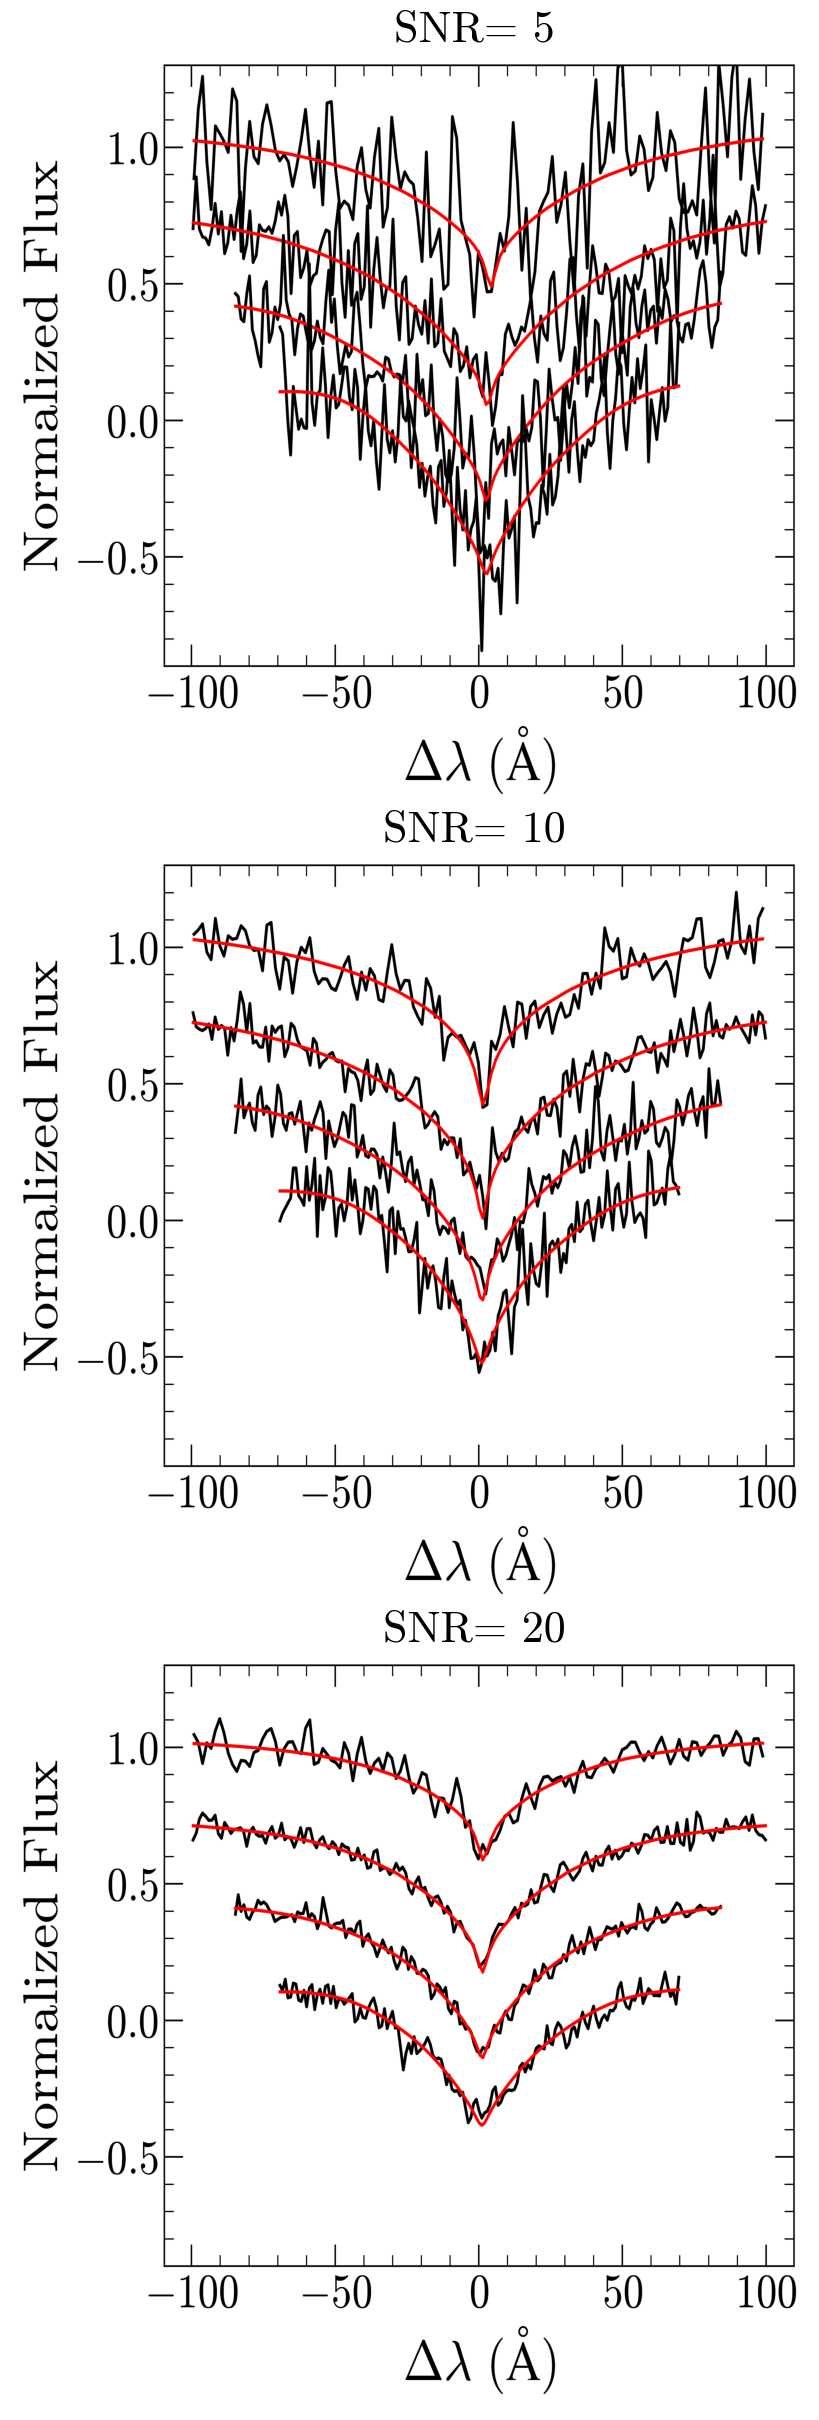

In [22]:
#combine the fit plots
fig=plt.figure(figsize=(8,24))
plt.style.use('stefan.mplstyle')
plotnum=1
for i in range(len(snrs)):
    snr=snrs[i]
    # Load the saved image and add to the plot
    image = plt.imread('rv_fit_'+str(plotnum)+'.png')
    fig.add_subplot(3,1,int(plotnum))
    plt.imshow(image)
    plt.axis('off')
    plt.title('SNR= '+str(int(np.round(snr,0))),x=0.58)
    plotnum=plotnum+1

fig.tight_layout(pad=0)
#plt.savefig('rv_fit.pdf', dpi=300)#, pad_inches=0.3)

### Fit all the RVs

In [19]:
def parallelprocess_fit_montreal_SDSSV(i):
    obj_ids=id_SDSSV_dict['set_'+str(i)].astype(int)

    rv_corv_ind=np.array([])
    e_rv_corv_ind=np.array([])
    teff_corv_ind=np.array([])
    logg_corv_ind=np.array([])
    rv_corv_coadd=np.array([])
    e_rv_corv_coadd=np.array([])
    teff_corv_coadd=np.array([])
    logg_corv_coadd=np.array([])
    snr_coadd=np.array([])
    nexp_coadd=np.array([])
    for obj_id in tqdm(obj_ids):
        individual_rvs,e_individual_rvs,individual_teffs,individual_loggs,coadd_rv,e_coadd_rv,coadd_teff,coadd_logg,coadd_snr,nexp=fit_montreal_SDSSV(obj_id,SDSSV_dict['set_'+str(i)],plot=False)
        rv_corv_ind=np.append(rv_corv_ind,individual_rvs)
        e_rv_corv_ind=np.append(e_rv_corv_ind,e_individual_rvs)
        teff_corv_ind=np.append(teff_corv_ind,individual_teffs)
        logg_corv_ind=np.append(logg_corv_ind,individual_loggs)
        rv_corv_coadd=np.append(rv_corv_coadd,np.full(len(individual_rvs),coadd_rv))
        teff_corv_coadd=np.append(teff_corv_coadd,np.full(len(individual_teffs),coadd_teff))
        logg_corv_coadd=np.append(logg_corv_coadd,np.full(len(individual_loggs),coadd_logg))
        e_rv_corv_coadd=np.append(e_rv_corv_coadd,np.full(len(individual_rvs),e_coadd_rv))
        snr_coadd=np.append(snr_coadd,np.full(len(individual_rvs),coadd_snr))
        nexp_coadd=np.append(nexp_coadd,np.full(len(individual_rvs),nexp))
    
    SDSSV_dict['set_'+str(i)]['rv_corv_ind']=rv_corv_ind.flatten()
    SDSSV_dict['set_'+str(i)]['e_rv_corv_ind']=e_rv_corv_ind.flatten()
    SDSSV_dict['set_'+str(i)]['teff_corv_ind']=teff_corv_ind.flatten()
    SDSSV_dict['set_'+str(i)]['logg_corv_ind']=logg_corv_ind.flatten()
    SDSSV_dict['set_'+str(i)]['rv_corv_coadd']=rv_corv_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['e_rv_corv_coadd']=e_rv_corv_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['teff_corv_coadd']=teff_corv_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['logg_corv_coadd']=logg_corv_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['snr_coadd']=snr_coadd.flatten()
    SDSSV_dict['set_'+str(i)]['nspec_coadd']=nexp_coadd.flatten()

    #save as a .csv
    SDSSV_dict['set_'+str(i)].to_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv',index=False)
    #save to backup
    SDSSV_dict['set_'+str(i)].to_csv('csv/SDSSV_short_sets/set_'+str(i)+'_nb03.csv',index=False)
    

In [20]:
def parallelprocess_fit_montreal_eSDSS(i):
    obj_ids=id_eSDSS_dict['set_'+str(i)].astype(int)

    rv_corv_ind=np.array([])
    e_rv_corv_ind=np.array([])
    teff_corv_ind=np.array([])
    logg_corv_ind=np.array([])
    rv_corv_coadd=np.array([])
    e_rv_corv_coadd=np.array([])
    teff_corv_coadd=np.array([])
    logg_corv_coadd=np.array([])
    snr_coadd=np.array([])
    nexp_coadd=np.array([])
    for obj_id in tqdm(obj_ids):
        individual_rvs,e_individual_rvs,individual_teffs,individual_loggs,coadd_rv,e_coadd_rv,coadd_teff,coadd_logg,coadd_snr,nexp=fit_montreal_eSDSS(obj_id,eSDSS_dict['set_'+str(i)],plot=False)
        rv_corv_ind=np.append(rv_corv_ind,individual_rvs)
        e_rv_corv_ind=np.append(e_rv_corv_ind,e_individual_rvs)
        teff_corv_ind=np.append(teff_corv_ind,individual_teffs)
        logg_corv_ind=np.append(logg_corv_ind,individual_loggs)
        rv_corv_coadd=np.append(rv_corv_coadd,np.full(len(individual_rvs),coadd_rv))
        teff_corv_coadd=np.append(teff_corv_coadd,np.full(len(individual_teffs),coadd_teff))
        logg_corv_coadd=np.append(logg_corv_coadd,np.full(len(individual_loggs),coadd_logg))
        e_rv_corv_coadd=np.append(e_rv_corv_coadd,np.full(len(individual_rvs),e_coadd_rv))
        snr_coadd=np.append(snr_coadd,np.full(len(individual_rvs),coadd_snr))
        nexp_coadd=np.append(nexp_coadd,np.full(len(individual_rvs),nexp))
    
    eSDSS_dict['set_'+str(i)]['rv_corv_ind']=rv_corv_ind.flatten()
    eSDSS_dict['set_'+str(i)]['e_rv_corv_ind']=e_rv_corv_ind.flatten()
    eSDSS_dict['set_'+str(i)]['teff_corv_ind']=teff_corv_ind.flatten()
    eSDSS_dict['set_'+str(i)]['logg_corv_ind']=logg_corv_ind.flatten()
    eSDSS_dict['set_'+str(i)]['rv_corv_coadd']=rv_corv_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['e_rv_corv_coadd']=e_rv_corv_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['teff_corv_coadd']=teff_corv_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['logg_corv_coadd']=logg_corv_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['snr_coadd']=snr_coadd.flatten()
    eSDSS_dict['set_'+str(i)]['nspec_coadd']=nexp_coadd.flatten()
    
    #save as a .csv
    eSDSS_dict['set_'+str(i)].to_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv',index=False)
    #save to backup
    eSDSS_dict['set_'+str(i)].to_csv('csv/eSDSS_short_sets/set_'+str(i)+'_nb03.csv',index=False)
    

In [ ]:
#run for each set of SDSSV ids
print(SDSSV_num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_fit_montreal_SDSSV)(i) for i in range(SDSSV_num_id_sets))

In [ ]:
#run for each set of eSDSS ids
print(eSDSS_num_id_sets)
#set n_jobs=-2 to spawn n-1 CPU threads where n=total number CPUs available
result=Parallel(n_jobs=-2, verbose=11)(delayed(parallelprocess_fit_montreal_eSDSS)(i) for i in range(eSDSS_num_id_sets))

### Read back in the short tables
The above method saves the .csv but doesn't overwrite the dataframe, so you have to read back in the results

In [23]:
#read in all data tables
SDSSV_dict={}
for i in tqdm(range(SDSSV_num_id_sets)):
    SDSSV_dict['set_'+str(i)]=pd.read_csv('csv/SDSSV_short_sets/set_'+str(i)+'.csv')

100%|███████████████████████████████████████████| 22/22 [00:00<00:00, 89.30it/s]


In [24]:
#read in all data tables
eSDSS_dict={}
for i in tqdm(range(eSDSS_num_id_sets)):
    eSDSS_dict['set_'+str(i)]=pd.read_csv('csv/eSDSS_short_sets/set_'+str(i)+'.csv')

100%|██████████████████████████████████████████| 49/49 [00:00<00:00, 169.25it/s]


### Combine all the dataframes together and save
Keep SDSS-V and eSDSS separate

In [25]:
#combine all the dataframes together
SDSSV_tab=SDSSV_dict['set_0'].append(SDSSV_dict['set_1'])
for i in tqdm(range(SDSSV_num_id_sets-2)):
    SDSSV_tab=SDSSV_tab.append(SDSSV_dict['set_'+str(i+2)])
#reset the indices
indices=np.arange(0,len(SDSSV_tab))
SDSSV_tab.set_index(indices,inplace=True)
#save as a .csv
SDSSV_tab.to_csv('csv/SDSSV_DA_df.csv',index=False)
#save to backup
SDSSV_tab.to_csv('csv/SDSSV_DA_df_nb03.csv',index=False)

100%|██████████████████████████████████████████| 20/20 [00:00<00:00, 294.37it/s]


In [26]:
#combine all the dataframes together
eSDSS_tab=eSDSS_dict['set_0'].append(eSDSS_dict['set_1'])
for i in tqdm(range(eSDSS_num_id_sets-2)):
    eSDSS_tab=eSDSS_tab.append(eSDSS_dict['set_'+str(i+2)])
#reset the indices
indices=np.arange(0,len(eSDSS_tab))
eSDSS_tab.set_index(indices,inplace=True)
#save as a .csv
eSDSS_tab.to_csv('csv/eSDSS_DA_df.csv',index=False)
#save to backup
eSDSS_tab.to_csv('csv/eSDSS_DA_df_nb03.csv',index=False)

100%|██████████████████████████████████████████| 47/47 [00:00<00:00, 484.62it/s]


# Failed Fits

In [ ]:
#look into the SDSSV individual failed fits
failed_fit_mask=SDSSV_tab['e_rv_corv_ind'].isna()
failed_fits=SDSSV_tab[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    # Open the SDSS-V fits file
    fieldid=str(failed_fits['fieldid'][ind])
    if len(fieldid)<6:
        fieldid='0'+fieldid
    mjd=str(failed_fits['mjd'][ind])
    catalogid=str(failed_fits['catalogid'][ind])
    fitsfilename='spec-'+fieldid+'-'+mjd+'-'+catalogid+'.fits'
    url='https://data.sdss5.org/sas/ipl-3/spectro/boss/redux/v6_1_1/spectra/lite/'+fieldid+'/'+mjd+'/'+fitsfilename 
    
    with fits.open(url, use_fsspec=True, fsspec_kwargs={"auth":aiohttp.BasicAuth(username, password)}) as spec:
        # Get pertinent spectrum data    
        fl = np.array(spec[1].data['flux'])
        #plot the spectrum
        ymin=-10
        ymax=max(fl[500:])
        (wl_array,flux_array,ivar_array,spec_fig)=plot_spectrum(spec,SDSSType='SDSSV',ylim=(ymin,ymax))
        plt.show()

#all failed fits have snr<10 and have very noisy spectra or big artifacts that disrupted the fit

In [ ]:
#look into the eSDSS failed fits
failed_fit_mask=eSDSS_tab['e_rv_corv_ind'].isna()
failed_fits=eSDSS_tab[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    # Open the saved eSDSS spectrum
    plate=failed_fits['plate'].loc[ind]
    mjd=failed_fits['mjd'].loc[ind]
    fiber=failed_fits['fiber'].loc[ind]   
    filename=str(failed_fits['pmf'].loc[ind])
    #plot the spectrum
    ymin=-10
    ymax=max(fl[500:])
    (wl_array,flux_array,ivar_array,spec_fig)=plot_spectrum(filename,SDSSType='eSDSS',ylim=(ymin,ymax))
    plt.show()

#all failed fits have snr<10 or are missing chunks of the spectrum

In [ ]:
#look into the SDSSV coadd failed fits
failed_fits=SDSSV_tab.query('nspec_coadd>1').drop_duplicates(subset='gaia_dr3_source_id')
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

failed_fit_mask=failed_fits['e_rv_corv_coadd'].isna()
failed_fits=failed_fits[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    obj_id=failed_fits['gaia_dr3_source_id'][ind]
    #import data
    npzfile = np.load('csv/SDSSV_coadds/'+str(obj_id)+'.npz')
    coadd_wl = npzfile['wavl'] #wavelength in angstroms
    coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
    coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
    coadd_snr = npzfile['snr']

    print('Coadded Spectrum, SNR='+str(coadd_snr))
    #plot the spectrum
    ymin=-10
    ymax=max(fl[500:])
    spec=[coadd_wl,coadd_fl,coadd_ivar]
    output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
    plt.show()

#no failed fits

In [ ]:
#look into the eSDSS coadd failed fits
failed_fits=eSDSS_tab.query('nspec_coadd>1').drop_duplicates(subset='gaia_dr3_source_id')
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

failed_fit_mask=failed_fits['e_rv_corv_coadd'].isna()
failed_fits=failed_fits[failed_fit_mask]
display(failed_fits)
#reset the indices
indices=np.arange(0,len(failed_fits))
failed_fits.set_index(indices,inplace=True)

#plot these spectra
for ind in tqdm(range(len(failed_fits))):
    obj_id=failed_fits['gaia_dr3_source_id'][ind]
    #import data
    npzfile = np.load('csv/eSDSS_coadds/'+str(obj_id)+'.npz')
    coadd_wl = npzfile['wavl'] #wavelength in angstroms
    coadd_fl = npzfile['flux'] #flux in 10^-17 ergs/s/cm^2/angstrom
    coadd_ivar = npzfile['ivar']#inverse variance of the flux, the error on the flux is ivar^-0.5
    coadd_snr = npzfile['snr']

    print('Coadded Spectrum, SNR='+str(coadd_snr))
    #plot the spectrum
    ymin=-10
    ymax=max(fl[500:])
    spec=[coadd_wl,coadd_fl,coadd_ivar]
    output=plot_spectrum(spec,SDSSType='coadd',ylim=(ymin,ymax))
    plt.show()

#no failed fits

# Binary Flag

### 0 = No evidence for binarity

### 1 = Evidence for binarity from RV variation across multiple observations  GAUTHAM
- Citation: https://academic.oup.com/mnras/article/468/3/2910/3038256
- For objects with multiple coadd RV observations (need good enough data quality), essentially a t-test but for more than 2 dimensions
- Gautham: Defining an eta value to confidently identify a binary is tricky. I use eta >3 for high confident binary classification (the paper uses 2.5). Roughly N10^(-eta) (where N is number of WDs with more than one epoch) should give you a rough expectation for number of WDs which RV variation consistent with gaussian noise. This might get tricky in your case since a majority of WDs have a single epoch of observations, but it is a good estimate.

### 2 = Evidence for binarity from Gaia Renormalised Unit Weight Error (RUWE)
https://gea.esac.esa.int/archive/documentation/GDR2/Gaia_archive/chap_datamodel/sec_dm_main_tables/ssec_dm_ruwe.html
- The RUWE is expected to be around 1.0 for sources where the single-star model provides a good fit to the astrometric observations. A value significantly greater than 1.0 (say, >1.4) could indicate that the source is non-single or otherwise problematic for the astrometric solution.
- Query Gaia to get the RUWE for each gaia_dr3_source_id, add to the dataframe
- Use ruwe < 1.2 cutoff to flag potential binaries
    - Citation for 1.2 cut: https://ui.adsabs.harvard.edu/abs/2025AJ....169...29S/abstract

### 3 = Evidence for binarity from both RV variation and RUWE

In [27]:
binary_info=pd.concat([SDSSV_tab[['gaia_dr3_source_id','fieldid','mjd','catalogid','snr','rv_corv_ind','e_rv_corv_ind']],
                       eSDSS_tab[['gaia_dr3_source_id','plate','mjd','fiber','snr','rv_corv_ind','e_rv_corv_ind']]])

binary_info_unique=binary_info.drop_duplicates(subset='gaia_dr3_source_id')

print(len(binary_info),len(binary_info_unique))

42066 26041


In [28]:
#Gautham's method for identifying binaries from RV variation
chi2 = sc.stats.chi2

source_ids=binary_info_unique['gaia_dr3_source_id'].to_list()

etas=[]
for source in source_ids:
    #need snr>10 for rv to be at all reliable
    tmp=binary_info.query('gaia_dr3_source_id==@source and snr>10')
    
    if len(tmp)>1:
        #get all rvs and errors on the rvs for one WD
        rv=tmp['rv_corv_ind']
        erv=tmp['e_rv_corv_ind']

        #characterize significance of RV variation
        rv_avg = np.average(rv,weights=1/erv**2)
        chi2_rv = np.sum((rv-rv_avg)**2/erv**2) # chi2 for RV variation
        sf_rv = chi2.sf(chi2_rv,len(rv)-1) # survival function for (n-1) degrees of freedom
        if sf_rv==0:
            display(tmp)
            eta=np.inf
        else:  
            eta = -np.log10(sf_rv)
    else:
        eta=0
    etas.append(eta)
    
binary_info_unique['eta']=etas

,gaia_dr3_source_id,fieldid,mjd,catalogid,snr,rv_corv_ind,e_rv_corv_ind,plate,fiber
7344,933556290482790528,NaN,55243,NaN,64.866066,108.054579,3.575797,3681.0,638.0
7345,933556290482790528,NaN,55246,NaN,52.950832,-121.718153,4.358716,3684.0,430.0


In [29]:
#add RUWE information to dataframe

query = f"""select source_id as gaia_dr3_source_id, ruwe
        from gaiadr3.gaia_source
        where source_id in {tuple(binary_info_unique['gaia_dr3_source_id'])}
        """
gaiadata = Gaia.launch_job_async(query=query, dump_to_file=False).get_results().to_pandas()

binary_info_unique=binary_info_unique.merge(gaiadata, on='gaia_dr3_source_id', how='outer')

INFO: Query finished. [astroquery.utils.tap.core]


In [30]:
#add binary flag to the data
binary_flag=[]
for i in range(len(binary_info_unique)):
    ruwe=binary_info_unique['ruwe'].to_list()[i]
    eta=binary_info_unique['eta'].to_list()[i]
    
    rv_flag=False
    ruwe_flag=False
    if eta>2.5:
        rv_flag=True
    if ruwe>1.2:
        ruwe_flag=True
        
    if rv_flag==False and ruwe_flag==False:
        binary_flag.append(0)
    if rv_flag==True and ruwe_flag==False:
        binary_flag.append(1)
    if rv_flag==False and ruwe_flag==True:
        binary_flag.append(2)
    if rv_flag==True and ruwe_flag==True:
        binary_flag.append(3)
        
binary_info_unique['binary_flag']=binary_flag

In [32]:
print(len(binary_info_unique.query('binary_flag==0')))
print(len(binary_info_unique.query('binary_flag==1')))
print(len(binary_info_unique.query('binary_flag==2')))
print(len(binary_info_unique.query('binary_flag==3')))

25593
211
234
3


In [33]:
#add the new columns
binary_info_merge=binary_info_unique[['gaia_dr3_source_id','eta','ruwe','binary_flag']]

print(len(SDSSV_tab),len(eSDSS_tab))
SDSSV_tab=pd.merge(left=SDSSV_tab,right=binary_info_merge,on='gaia_dr3_source_id',how="left")
eSDSS_tab=pd.merge(left=eSDSS_tab,right=binary_info_merge,on='gaia_dr3_source_id',how="left")
print(len(SDSSV_tab),len(eSDSS_tab))

for j in tqdm(range(SDSSV_num_id_sets)):
    SDSSV_dict['set_'+str(j)]=pd.merge(left=SDSSV_dict['set_'+str(j)],right=binary_info_merge,on='gaia_dr3_source_id',how="left")

for j in tqdm(range(eSDSS_num_id_sets)):
    eSDSS_dict['set_'+str(j)]=pd.merge(left=eSDSS_dict['set_'+str(j)],right=binary_info_merge,on='gaia_dr3_source_id',how="left")


16651 25415
16651 25415


100%|██████████████████████████████████████████| 49/49 [00:00<00:00, 520.61it/s]


# Define functions to compare the corv fits to the other datasets and to compare the coadd/mean RVs to the individual RVs


In [34]:
def comparison_stats(wd_table,cat1,cat2,meas_param,unit):
    
    error=wd_table[meas_param+'_'+cat1]-wd_table[meas_param+'_'+cat2]
    frac_err=error/wd_table[meas_param+'_'+cat1]
    
    #calculate the rmse between the datasets
    rmse = 0
    for i in range(len(wd_table)):
        rmse += (error[i])**2
    rmse = np.sqrt(rmse / len(wd_table))
    print(r''+meas_param+' RMSE: {:2.3f} '.format(rmse)+unit)
    
    #calculate the median absolute error between the datasets
    mae=np.median(np.abs(error))
    print(meas_param+' MAE: {:2.3f} '.format(mae)+unit)

    #calculate the bias between the datasets
    bias=np.median(error)
    print(meas_param+' BIAS: {:2.3f} '.format(bias)+unit)
    
    #calculate the median absolute fractional error
    med_frac=np.median(np.abs(frac_err))
    print(meas_param+' MED FRAC ERR: {:2.3f} '.format(med_frac))
        
    return(rmse,mae,bias,med_frac,error,frac_err)

In [35]:
def comparison_plots(wd_table,cat1,cat2,meas_param,unit,SDSSType='SDSSV',statx=100,staty=60,statdy=10,lim='default',
                   siegel=True,plthist=True,savefig=False):
    
    directcompplotname='DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    directcompplottrendname='Trendlines_'+'DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    Abserrplotname='Abserrplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    Histplotname='Histplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    
    if cat1!='corv_ind' and cat1!='corv_coadd' and cat1!='corv_mean':
        if SDSSType=='SDSSV':
            #cat1 is comparison catalog, so find only observations with data from that catalog
            wd_table=wd_table.query(cat1+'_flag==True')
            #reset the indices
            indices=np.arange(0,len(wd_table))
            wd_table.set_index(indices,inplace=True)
        else:
            #drop nans
            wd_table=wd_table[[meas_param+'_'+cat1,'e_'+meas_param+'_'+cat1,meas_param+'_'+cat2,'e_'+meas_param+'_'+cat2,'snr']]
            wd_table=wd_table.dropna()
            #reset the indices
            indices=np.arange(0,len(wd_table))
            wd_table.set_index(indices,inplace=True)
    
    #calculate stats
    rmse,mae,bias,med_frac,error,frac_err=comparison_stats(wd_table,cat1,cat2,meas_param,unit)
    
    #plot the agreement between the datasets, with stats
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.text(statx, staty, 'RMSE = {:.3f} '.format(rmse)+unit)
    ax1.text(statx, staty-1*statdy, 'MAE = {:.3f} '.format(mae)+unit)
    ax1.text(statx, staty-2*statdy, 'Bias = {:.3f} '.format(bias)+unit)
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    maxval=max(max(wd_table[meas_param+'_'+cat1]),max(wd_table[meas_param+'_'+cat2]))
    minval=min(min(wd_table[meas_param+'_'+cat1]),min(wd_table[meas_param+'_'+cat2]))
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplotname)
    plt.show()
    
    #plot the agreement between the datasets, with trendlines
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    #add a linear trendlines
    if siegel==True:
        coef = stats.siegelslopes(wd_table[meas_param+'_'+cat2], wd_table[meas_param+'_'+cat1])
        poly1d_fn = np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    else:
        coef= np.polyfit(wd_table[meas_param+'_'+cat1],wd_table[meas_param+'_'+cat2],1)
        poly1d_fn= np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplottrendname)
    plt.show()

    # plot the fractional error between the datasets
    #frac_err=(cat1-cat2)/cat1
    # as a function of cat1 dataset param and spectrum snr
    fig, (ax1,ax2) =plt.subplots(1,2,figsize=(16,8))
    plt.style.use('stefan.mplstyle')
    ax1.scatter(wd_table[meas_param+'_'+cat1], frac_err)
    ax2.scatter(wd_table['snr'], frac_err)
    ax1.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax1.axhline(-med_frac,color='green')
    ax2.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax2.axhline(-med_frac,color='green')
    ax1.legend()
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax2.set_xlabel(r'Median SNR')
    ax1.set_ylabel(r'(Cat1-Cat2)/Cat1')
    ax2.set_xlim((0,100))
    plt.show()
    
    # re-plot for smaller window
    fig, (ax1,ax2) =plt.subplots(1,2,figsize=(16,8))
    plt.style.use('stefan.mplstyle')
    ax1.scatter(wd_table[meas_param+'_'+cat1], frac_err)
    ax2.scatter(wd_table['snr'], frac_err)
    ax1.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax1.axhline(-med_frac,color='green')
    ax2.axhline(med_frac,color='green',label='MED ABS FRAC ERR = {:.3f}'.format(med_frac))
    ax2.axhline(-med_frac,color='green')
    ax1.legend()
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax2.set_xlabel(r'Median SNR')
    ax1.set_ylabel(r'(Cat1-Cat2)/Cat1')
    ax2.set_xlim((0,100))
    ax1.set_ylim((-1,1))
    ax2.set_ylim((-1,1))
    if savefig==True:
        plt.savefig('plots/'+Abserrplotname)
    plt.show()
    
    if plthist==True:
        # plot a histogram of cat1_val-cat2_val/sqrt(cat1_err^2+cat2_err^2)
        #normalize to 1 count using the density=True option
        #this histogram should be ~ gaussion with mean ~ 0 and std ~ 1
        fig, ax1 =plt.subplots(1,1,figsize=(6,6))
        plt.style.use('stefan.mplstyle')
        norm_err=error/np.sqrt(wd_table['e_'+meas_param+'_'+cat1]**2+wd_table['e_'+meas_param+'_'+cat2]**2)
        ax1.hist(norm_err, density=True)
        #fit a gaussian to the histogram
        mu, std = norm.fit(norm_err.dropna()) 
        xmin, xmax = plt.xlim()
        x = np.linspace(xmin, xmax, 100)
        p = norm.pdf(x, mu, std)
        ax1.plot(x, p, 'k', linewidth=2,label="$\mu$={:.2f}\n$\sigma$={:.2f}".format(mu, std))
        ax1.legend()
        ax1.set_xlabel(r''+meas_param+' Normalized Error')
        ax1.set_ylabel(r'Normalized Counts')
        if savefig==True:
            plt.savefig('plots/'+Histplotname)
        plt.show()

# Compare the corv fits to the other datasets
The Falcon, Raddi, Anguiano, and Kepler datasets contain RV measurements, compare the individual observation SDSS-V corv RVs to these catalogs

Also compare the eSDSS fits to the individual observations to the results from corresponding SDSS DRs

In [ ]:
#For Falcon data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'falcon','corv_ind','rv','km/s',statx=-20,staty=60,statdy=10)


In [ ]:
#For Raddi data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'raddi','corv_ind','rv','km/s',statx=30,staty=-50,statdy=20)


In [ ]:
#For Anguiano data with SDSS_SN>20
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'anguiano','corv_ind','rv','km/s',statx=180,staty=0,statdy=30)


In [ ]:
#For Kepler data with SDSS_SN>20
#comparison_plots(SDSSV_tab.query('snr>20'),'Kepler','corv_ind','RV','km/s',statx=-1000,staty=-50,statdy=100)
#zoomed in
comparison_plots(SDSSV_tab.query('snr>20 & binary_flag==0'),'kepler','corv_ind','rv','km/s',statx=-180,staty=170,statdy=20,lim=(-200,200))


In [ ]:
#For earlier DR data with SDSS_SN>20
comparison_plots(eSDSS_tab.query('snr>20 & binary_flag==0'),'sdss_dr','corv_ind','rv','km/s',SDSSType='eSDSS',statx=-200,staty=400,statdy=80)


# Systematic Error

In [41]:
def binned_diff(comparison_set,diff_param,bin_param,bins,snr_cut=0,cut_param=None,cut=None,absolute_val=True):
    # calculate the difference between our measured parameter (rv, logg, or teff) and a comparison set
    # measured parameter binned in some parameter (ie. snr or as function of the measured param)
    
    #implement snr and binarity cut
    SDSSV_tab_cut=SDSSV_tab.query('snr>@snr_cut & binary_flag==0')
    eSDSS_tab_cut=eSDSS_tab.query('snr>@snr_cut & binary_flag==0')
    
    #remove nans
    if diff_param=='rv':
        SDSSV_tab_cut=SDSSV_tab_cut.dropna(subset='rv_corv_ind')
        eSDSS_tab_cut=eSDSS_tab_cut.dropna(subset='rv_corv_ind')
    if diff_param=='logg':
        SDSSV_tab_cut=SDSSV_tab_cut.dropna(subset='logg_prf_ind')
        eSDSS_tab_cut=eSDSS_tab_cut.dropna(subset='logg_prf_ind')
    if diff_param=='teff':
        SDSSV_tab_cut=SDSSV_tab_cut.dropna(subset='teff_prf_ind')
        eSDSS_tab_cut=eSDSS_tab_cut.dropna(subset='teff_prf_ind')
        
    #implement data quality cut if desired
    #cut must be string containing the comparative > or < also
    if cut_param!=None:
        SDSSV_tab_cut=SDSSV_tab_cut.query("`{0}` {1}".format(cut_param,cut))
        eSDSS_tab_cut=eSDSS_tab_cut.query("`{0}` {1}".format(cut_param,cut))
    
    if comparison_set=='internal':
        #get all objects with at least 2 observations for which at least 1 has snr>20
        #compare our measurements on lower snr spectra to our measurements on higher snr spectra
        mult_obs=SDSSV_tab_cut.query('nspec_coadd>1 & snr>20')
        gaia_ids=mult_obs['gaia_dr3_source_id'].unique()
        max_snrs=[]
        bin_params=[]
        diffs=[]
        for i in range(len(gaia_ids)):
            gaia_id=gaia_ids[i]
            tmp=SDSSV_tab_cut.query('gaia_dr3_source_id==@gaia_id')
            #get highest snr observation
            max_snr=max(tmp['snr'])
            if diff_param=='rv':
                max_snr_param=tmp.query('snr==@max_snr')['rv_corv_ind'].to_list()[0]
            if diff_param=='logg':
                max_snr_param=tmp.query('snr==@max_snr')['logg_prf_ind'].to_list()[0]
            if diff_param=='teff':
                max_snr_param=tmp.query('snr==@max_snr')['teff_prf_ind'].to_list()[0]
            #take differences
            tmp_low_snr=tmp.query('snr!=@max_snr')
            #reset the indices
            indices=np.arange(0,len(tmp_low_snr))
            tmp_low_snr.set_index(indices,inplace=True)
            for j in range(len(tmp_low_snr)):
                bin_param_val=tmp_low_snr[bin_param].to_list()[j]
                if diff_param=='rv':
                    param_val=tmp_low_snr['rv_corv_ind'].to_list()[j]
                if diff_param=='logg':
                    param_val=tmp_low_snr['logg_prf_ind'].to_list()[j]
                if diff_param=='teff':
                    param_val=tmp_low_snr['teff_prf_ind'].to_list()[j]
                if absolute_val==True:
                    diff=np.abs(param_val-max_snr_param)
                else:
                    diff=max_snr_param-param_val
                max_snrs.append(max_snr)
                bin_params.append(bin_param_val)
                diffs.append(diff)
        #repeat for eSDSS
        mult_obs=eSDSS_tab_cut.query('nspec_coadd>1 & snr>20')
        gaia_ids=mult_obs['gaia_dr3_source_id'].unique()
        for i in range(len(gaia_ids)):
            gaia_id=gaia_ids[i]
            tmp=eSDSS_tab_cut.query('gaia_dr3_source_id==@gaia_id')
            #get highest snr observation
            max_snr=max(tmp['snr'])
            if diff_param=='rv':
                max_snr_param=tmp.query('snr==@max_snr')['rv_corv_ind'].to_list()[0]
            if diff_param=='logg':
                max_snr_param=tmp.query('snr==@max_snr')['logg_prf_ind'].to_list()[0]
            if diff_param=='teff':
                max_snr_param=tmp.query('snr==@max_snr')['teff_prf_ind'].to_list()[0]
            #take differences
            tmp_low_snr=tmp.query('snr!=@max_snr')
            #reset the indices
            indices=np.arange(0,len(tmp_low_snr))
            tmp_low_snr.set_index(indices,inplace=True)
            for j in range(len(tmp_low_snr)):
                bin_param_val=tmp_low_snr[bin_param].to_list()[j]
                if diff_param=='rv':
                    param_val=tmp_low_snr['rv_corv_ind'].to_list()[j]
                if diff_param=='logg':
                    param_val=tmp_low_snr['logg_prf_ind'].to_list()[j]
                if diff_param=='teff':
                    param_val=tmp_low_snr['teff_prf_ind'].to_list()[j]
                if absolute_val==True:
                    diff=np.abs(param_val-max_snr_param)
                else:
                    diff=param_val-max_snr_param
                max_snrs.append(max_snr)
                bin_params.append(bin_param_val)
                diffs.append(diff)
                
        table=pd.DataFrame()
        table['max_snr']=max_snrs
        table[bin_param]=bin_params
        table['difference']=diffs

    else:
        #compare our measurements to another data set
        if comparison_set=='sdss_dr':
            table=eSDSS_tab_cut
            #get only those observations corresponding to the comparison set
            table=table.dropna(subset=[diff_param+'_sdss_dr',bin_param,'snr'])
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        else:
            table=SDSSV_tab_cut
            #get only those observations corresponding to the comparison set
            table=table.query(comparison_set+'_flag==True')
            table=table.dropna(subset=['snr',bin_param])
            #reset the indices
            indices=np.arange(0,len(table))
            table.set_index(indices,inplace=True)
        
        if diff_param=='rv':
            if absolute_val==True:
                diffs=np.abs(table['rv_'+comparison_set]-table['rv_corv_ind'])
            else:
                diffs=table['rv_'+comparison_set]-table['rv_corv_ind']
        if diff_param=='logg':
            if absolute_val==True:
                diffs=np.abs(table['logg_'+comparison_set]-table['logg_prf_ind'])
            else:
                diffs=table['logg_'+comparison_set]-table['logg_prf_ind']
        if diff_param=='teff':
            if absolute_val==True:
                diffs=np.abs(table['teff_'+comparison_set]-table['teff_prf_ind'])
            else:
                diffs=table['teff_'+comparison_set]-table['teff_prf_ind']
        table['difference']=diffs
    
    #bin by bin_param and take median error
    bin_ranges=[]
    bin_half_pts=[]
    for i in range(len(bins)-1):
        array=[bins[i],bins[i+1]]
        half=0.5*(bins[i]+bins[i+1])
        bin_ranges.append(array)
        bin_half_pts.append(half)
    bin_nums=np.arange(0,len(bin_ranges))
    
    bin_ids=[]
    bin_id_ranges=[]
    bin_id_centers=[]
    for i in range(len(table)):
        bin_param_val=table[bin_param][i]
        for j in range(len(bin_ranges)):
            if bin_ranges[j][0]<=bin_param_val<bin_ranges[j][1]:
                bin_ids.append(j)
                bin_id_ranges.append(bin_ranges[j])
                bin_id_centers.append(bin_half_pts[j])
    
    table['bin_id']=bin_ids
    table['bin_range']=bin_id_ranges
    table['bin_center']=bin_id_centers
    
    median_diffs=[]
    median_bin_params=[]
    num_obs_per_bin=[]
    for i in range(len(bin_nums)):
        tmp=table.query('bin_id=='+str(bin_nums[i]))
        diff=np.array(tmp['difference'].to_list())
        bin_params=np.array(tmp[bin_param].to_list())
        if len(diff)>0:
            #calculate median difference of bin
            median_diff=np.nanmedian(diff)
            median_bin_param=np.nanmedian(bin_params)
        else: #if bin is empty fill with nan values
            median_diff=np.nan
            median_bin_param=np.nan
        #record results
        median_diffs.append(median_diff)
        median_bin_params.append(median_bin_param)
        #record how many observations used in averaging
        num_obs=len(tmp)
        num_obs_per_bin.append(num_obs)
        
    output=pd.DataFrame()
    output['bin_id']=bin_nums
    output['bin_range']=bin_ranges
    output['bin_center']=bin_half_pts
    output['median_'+comparison_set]=median_diffs
    output['median_bin_param_'+comparison_set]=median_bin_params
    output['num_obs_per_bin_'+comparison_set]=num_obs_per_bin

    #re-order by bin_id
    output=output.sort_values(by=['bin_id'])

    return(output)

In [42]:
#calculate the differences binned in snr
snr_bins=np.round(np.arange(0,100,3),1)
mae_falcon_snr=binned_diff('falcon','rv','snr',snr_bins)
mae_raddi_snr=binned_diff('raddi','rv','snr',snr_bins)
mae_anguiano_snr=binned_diff('anguiano','rv','snr',snr_bins)
mae_kepler_snr=binned_diff('kepler','rv','snr',snr_bins)
mae_sdss_snr=binned_diff('sdss_dr','rv','snr',snr_bins)
mae_internal_snr=binned_diff('internal','rv','snr',snr_bins)

med_falcon_snr=binned_diff('falcon','rv','snr',snr_bins,absolute_val=False)
med_raddi_snr=binned_diff('raddi','rv','snr',snr_bins,absolute_val=False)
med_anguiano_snr=binned_diff('anguiano','rv','snr',snr_bins,absolute_val=False)
med_kepler_snr=binned_diff('kepler','rv','snr',snr_bins,absolute_val=False)
med_sdss_snr=binned_diff('sdss_dr','rv','snr',snr_bins,absolute_val=False)
med_internal_snr=binned_diff('internal','rv','snr',snr_bins,absolute_val=False)

In [43]:
#calculate the differences binned in rv
rv_bins=np.arange(-300,320,20)
rv_bins=np.insert(rv_bins,len(rv_bins),3000)
rv_bins=np.insert(rv_bins,0,-3000)

snr_cut=20

mae_falcon_rv=binned_diff('falcon','rv','rv_corv_ind',rv_bins,snr_cut)
mae_raddi_rv=binned_diff('raddi','rv','rv_corv_ind',rv_bins,snr_cut)
mae_anguiano_rv=binned_diff('anguiano','rv','rv_corv_ind',rv_bins,snr_cut)
mae_kepler_rv=binned_diff('kepler','rv','rv_corv_ind',rv_bins,snr_cut)
mae_sdss_rv=binned_diff('sdss_dr','rv','rv_corv_ind',rv_bins,snr_cut)
mae_internal_rv=binned_diff('internal','rv','rv_corv_ind',rv_bins,snr_cut)

med_falcon_rv=binned_diff('falcon','rv','rv_corv_ind',rv_bins,snr_cut,absolute_val=False)
med_raddi_rv=binned_diff('raddi','rv','rv_corv_ind',rv_bins,snr_cut,absolute_val=False)
med_anguiano_rv=binned_diff('anguiano','rv','rv_corv_ind',rv_bins,snr_cut,absolute_val=False)
med_kepler_rv=binned_diff('kepler','rv','rv_corv_ind',rv_bins,snr_cut,absolute_val=False)
med_sdss_rv=binned_diff('sdss_dr','rv','rv_corv_ind',rv_bins,snr_cut,absolute_val=False)
med_internal_rv=binned_diff('internal','rv','rv_corv_ind',rv_bins,snr_cut,absolute_val=False)

In [44]:
names=['falcon','raddi','anguiano','kepler','sdss_dr','internal']
labels=['Falcon','Raddi','Anguiano','Kepler','Published SDSS Catalog','Internal']
dataframes_snr=[mae_falcon_snr,mae_raddi_snr,mae_anguiano_snr,mae_kepler_snr,mae_sdss_snr,mae_internal_snr]
dataframes_rv=[mae_falcon_rv,mae_raddi_rv,mae_anguiano_rv,mae_kepler_rv,mae_sdss_rv,mae_internal_rv]

dataframes_snr_med=[med_falcon_snr,med_raddi_snr,med_anguiano_snr,med_kepler_snr,med_sdss_snr,med_internal_snr]
dataframes_rv_med=[med_falcon_rv,med_raddi_rv,med_anguiano_rv,med_kepler_rv,med_sdss_rv,med_internal_rv]


/Users/nicolecrumpler/anaconda3/envs/wd_models/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


sys uncertainty=33.8*exp(-0.2*x)+7.4


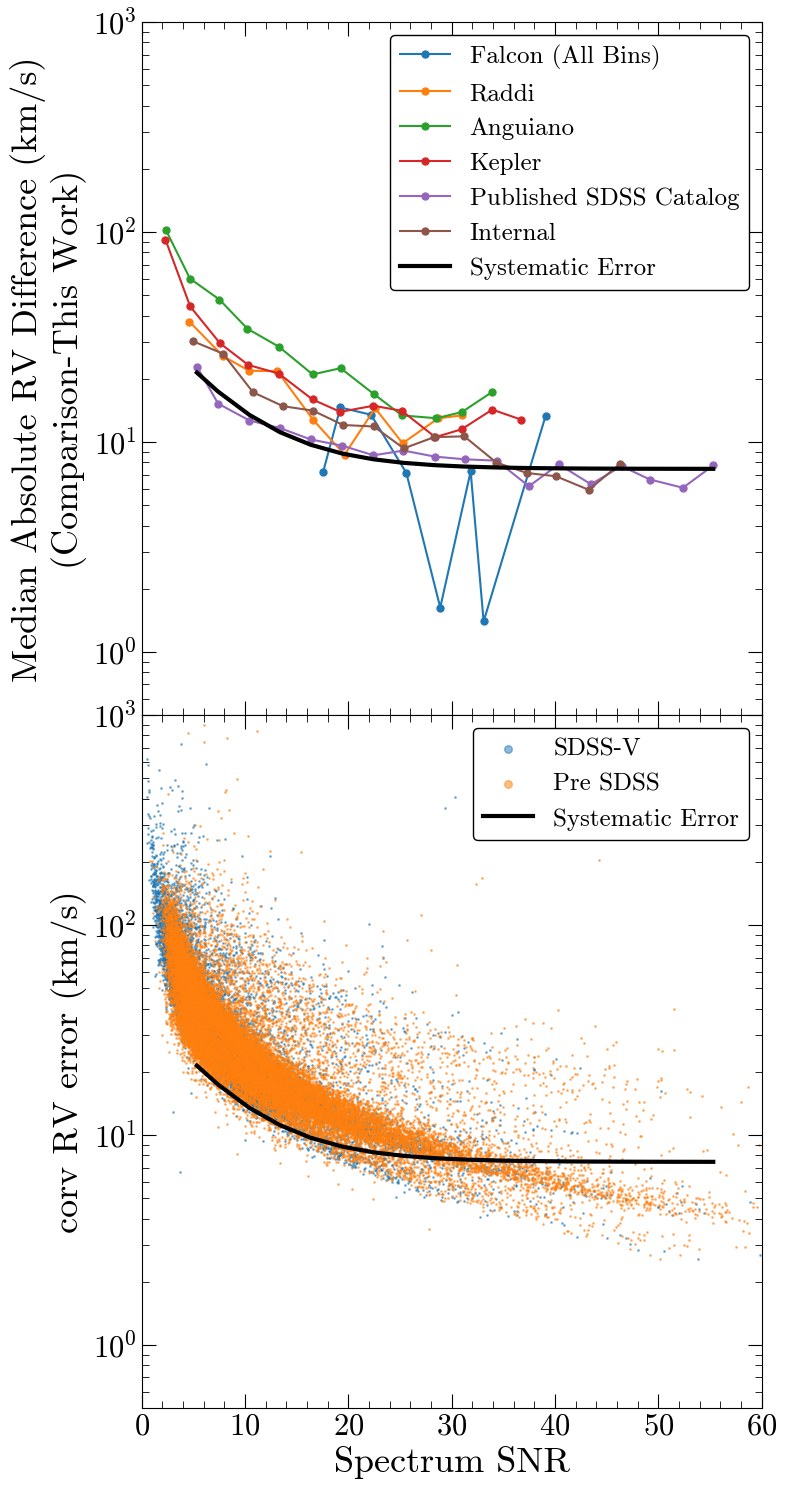

In [45]:
#plot the differences
min_num_obs=20

#drop nans for falcon for better plotting
mae_falcon_snr=mae_falcon_snr.dropna()

#model the snr agreement as a decaying exponential, fit sdss_dr agreement using bins with bin counts>min_num_obs
def exp(x, a, c, d):
    return a*np.exp(-c*x)+d
name='sdss_dr'
x=mae_sdss_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name]
y=mae_sdss_snr.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name]
nanmask=np.logical_not(np.isnan(x))
x=x[nanmask]
y=y[nanmask]
popt, pcov = curve_fit(exp, x, y)#, p0=(1, 1e-6, 1))
def rv_err(snr_array):
    result=[]
    for snr in snr_array:
        result.append(exp(snr, popt[0], popt[1], popt[2]))
    return(result)
#print the error function
print('sys uncertainty='+str(np.round(popt[0],1))+'*exp(-'+str(np.round(popt[1],1))+'*x)+'+str(np.round(popt[2],1)))

#plot
fig, ((ax1),(ax2)) =plt.subplots(2,1,figsize=(8,18),sharey=True,sharex=True)
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_snr[i]
    if name=='falcon':
        #too few observations so don't cut on number of objects in bin
        ax1.plot(mae_falcon_snr['median_bin_param_'+name],mae_falcon_snr['median_'+name],'o-',label=label+' (All Bins)')
    else:
        ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
#plot the overall agreement
ax1.plot(x,rv_err(x),'k',linewidth=3,label='Systematic Error')
ax1.legend()
ax1.set_ylabel("Median Absolute RV Difference (km/s)\n(Comparison-This Work)")
ax1.set_yscale('log')

#plot the corv error as a function of SNR
ax2.scatter(SDSSV_tab['snr'],SDSSV_tab['e_rv_corv_ind'],s=1,alpha=0.5,rasterized=True,label='SDSS-V')
ax2.scatter(eSDSS_tab['snr'],eSDSS_tab['e_rv_corv_ind'],s=1,alpha=0.5,rasterized=True,label='Pre SDSS')
ax2.plot(x,rv_err(x),'k',linewidth=3,label='Systematic Error')
ax2.legend()
ax2.set_ylabel("corv RV error (km/s)")
ax2.set_xlabel("Spectrum SNR")
ax2.set_yscale('log')
#change the marker size manually
lgnd = ax2.legend(loc='upper right')
lgnd.legend_handles[0]._sizes = [30]
lgnd.legend_handles[1]._sizes = [30]

ax1.set_ylim(0.5,1000)
ax1.set_xlim(0,60)

plt.subplots_adjust(hspace=0,wspace=0.1)

plt.savefig('rv_err_snr.pdf', dpi=300)

#if file size is too big, flatten the pdf at https://www.sejda.com/flatten-pdf


In [46]:
print(rv_err([0]))
print(rv_err([5]))
print(rv_err([10]))
print(rv_err([20]))
print(rv_err([50]))

[41.26717333641015]
[22.229573313668684]
[13.908634793181422]
[8.682108681714192]
[7.456457708368556]


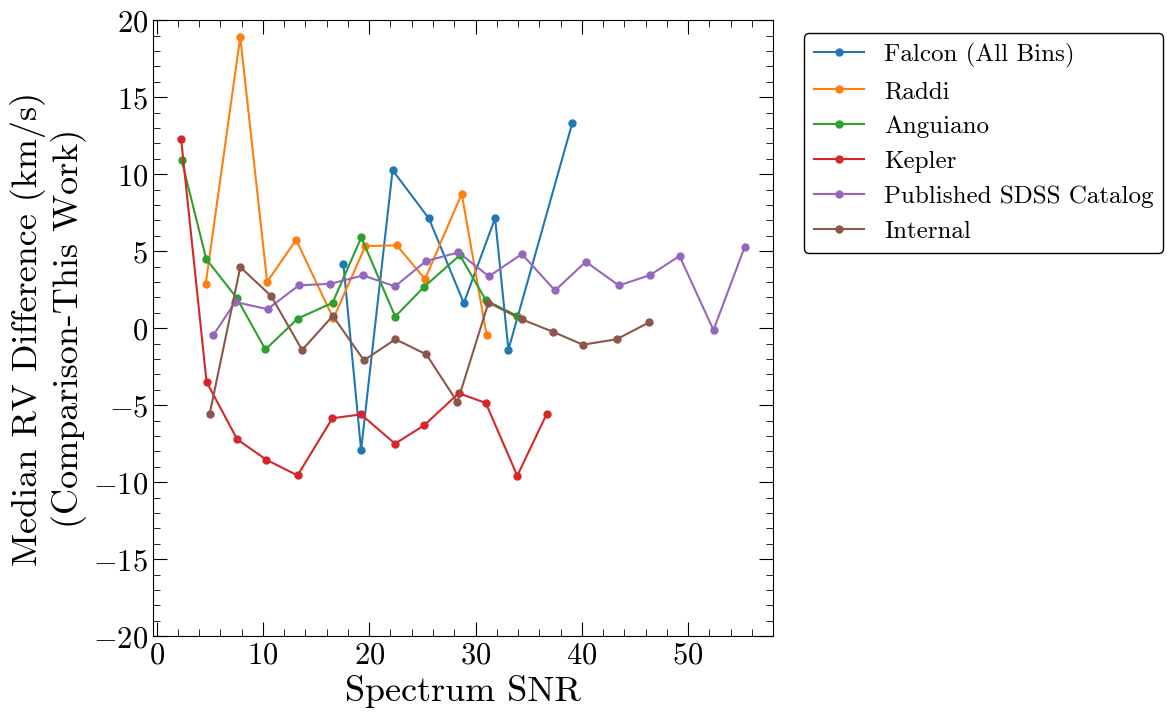

In [47]:
#plot the differences
min_num_obs=20

#drop nans for falcon for better plotting
med_falcon_snr=med_falcon_snr.dropna()

#plot
fig, ax1 =plt.subplots(1,1,figsize=(8,8))
plt.style.use('stefan.mplstyle')
#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_snr_med[i]
    if name=='falcon':
        #too few observations so don't cut on number of objects in bin
        ax1.plot(med_falcon_snr['median_bin_param_'+name],med_falcon_snr['median_'+name],'o-',label=label+' (All Bins)')
    else:
        ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax1.legend(bbox_to_anchor=(1.03, 1))
ax1.set_ylabel("Median RV Difference (km/s)\n(Comparison-This Work)")
ax1.set_xlabel("Spectrum SNR")

ax1.set_ylim(-20,20)


plt.subplots_adjust(wspace=0.1)

#plt.savefig('rv_err.pdf', dpi=300)



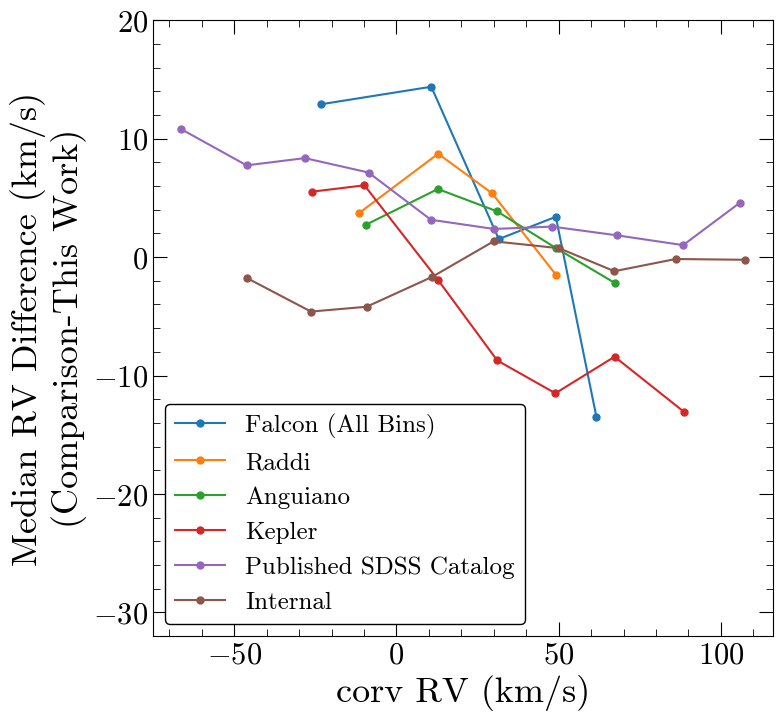

In [48]:
#plot the differences
min_num_obs=20

#drop nans for falcon for better plotting
med_falcon_rv=med_falcon_rv.dropna()

#plot
fig, ax1 =plt.subplots(1,1,figsize=(8,8))
plt.style.use('stefan.mplstyle')

#plot the agreement with each data set
for i in range(len(names)):
    name=names[i]
    label=labels[i]
    df=dataframes_rv_med[i]
    if name=='falcon':
        #too few observations so don't cut on number of objects in bin
        ax1.plot(med_falcon_rv['median_bin_param_'+name],med_falcon_rv['median_'+name],'o-',label=label+' (All Bins)')
    else:
        ax1.plot(df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_bin_param_'+name],df.query('num_obs_per_bin_'+name+'>@min_num_obs')['median_'+name],'o-',label=label)
ax1.set_ylabel("Median RV Difference (km/s)\n(Comparison-This Work)")
ax1.set_xlabel("corv RV (km/s)")
ax1.legend()#bbox_to_anchor=(1.03, 1))
ax1.set_ylim(-32,20)

plt.savefig('rv_err_rv.pdf', dpi=300)

# Calculating Full Error and Weighted Mean RV

In [49]:
snr_cut=10

#add this systematic error in quadrature to the statistical corv error to get the full error
#for individual exps and coadds
#the calculate the weighted mean rv of all spectra with SNR>10

for j in tqdm(range(SDSSV_num_id_sets)):
    obj_ids=id_SDSSV_dict['set_'+str(j)].astype(int)
    e_rv_corv_ind_full=np.array([])
    e_rv_corv_coadd_full=np.array([])
    rv_corv_mean=np.array([])
    e_rv_corv_mean=np.array([])
    nexp_mean=np.array([])
    for obj_id in obj_ids:
        table=SDSSV_dict['set_'+str(j)].query('gaia_dr3_source_id==@obj_id')
        #reset the indices
        indices=np.arange(0,len(table))
        table.set_index(indices,inplace=True)
        #get the parameters from the table
        ind_snrs=np.array(table['snr'].to_list())
        ind_rvs=np.array(table['rv_corv_ind'].to_list())
        e_ind_rvs=np.array(table['e_rv_corv_ind'].to_list())
        coadd_snrs=np.array(table['snr_coadd'].to_list())
        coadd_rvs=np.array(table['rv_corv_coadd'].to_list())
        e_coadd_rvs=np.array(table['e_rv_corv_coadd'].to_list())
        
        #use the fit to calculate the systematic rv errors
        sys_rv_err_ind=rv_err(ind_snrs)
        sys_rv_err_coadd=rv_err(coadd_snrs)
        #add this in quadrature to get the full error
        e_ind_rvs_full=np.sqrt(e_ind_rvs**2+np.full(len(e_ind_rvs),sys_rv_err_ind)**2)
        e_coadd_rvs_full=np.sqrt(e_coadd_rvs**2+np.full(len(e_coadd_rvs),sys_rv_err_coadd)**2)
        #save these parameters
        e_rv_corv_ind_full=np.append(e_rv_corv_ind_full,e_ind_rvs_full)
        e_rv_corv_coadd_full=np.append(e_rv_corv_coadd_full,e_coadd_rvs_full)
        
        #take weighted mean rv of spectra with SNR>snr_cut using the full error
        #check also that the fit did not fail by requiring e_individual_rv>0
        good_rvs=[]
        e_good_rvs=[]
        for i in range(len(ind_snrs)):
            if ind_snrs[i]>snr_cut and e_ind_rvs_full[i]>0:
                good_rvs.append(ind_rvs[i])
                e_good_rvs.append(e_ind_rvs_full[i])
        nhisnr=len(good_rvs) #count number of spectra averaged
        if nhisnr>0:
            #calculate weights
            rv_weights=(1/np.array(e_good_rvs))**2
            #calculate mean rv and error on mean
            mean_rv=np.average(good_rvs,weights=rv_weights)
            e_mean_rv=1/np.sqrt(np.sum(rv_weights))
        else:
            mean_rv=np.nan
            e_mean_rv=np.nan
        #save these parameters
        rv_corv_mean=np.append(rv_corv_mean,np.full(len(ind_rvs),mean_rv))
        e_rv_corv_mean=np.append(e_rv_corv_mean,np.full(len(ind_rvs),e_mean_rv))
        nexp_mean=np.append(nexp_mean,np.full(len(ind_rvs),nhisnr))

    #add everything to the table
    SDSSV_dict['set_'+str(j)]['e_rv_corv_ind_full']=e_rv_corv_ind_full.flatten()
    SDSSV_dict['set_'+str(j)]['e_rv_corv_coadd_full']=e_rv_corv_coadd_full.flatten()
    SDSSV_dict['set_'+str(j)]['rv_corv_mean']=rv_corv_mean.flatten()
    SDSSV_dict['set_'+str(j)]['e_rv_corv_mean']=e_rv_corv_mean.flatten()
    SDSSV_dict['set_'+str(j)]['nspec_mean_rv_corv']=nexp_mean.flatten()
    #save as a .csv
    SDSSV_dict['set_'+str(j)].to_csv('csv/SDSSV_short_sets/set_'+str(j)+'.csv',index=False)
    #save to back up
    SDSSV_dict['set_'+str(j)].to_csv('csv/SDSSV_short_sets/set_'+str(j)+'_nb03.csv',index=False)
    

100%|███████████████████████████████████████████| 22/22 [00:15<00:00,  1.46it/s]


In [50]:
snr_cut=10

#add this systematic error in quadrature to the statistical corv error to get the full error
#for individual exps and coadds
#the calculate the weighted mean rv of all spectra with SNR>10

for j in tqdm(range(eSDSS_num_id_sets)):
    obj_ids=id_eSDSS_dict['set_'+str(j)].astype(int)
    e_rv_corv_ind_full=np.array([])
    e_rv_corv_coadd_full=np.array([])
    rv_corv_mean=np.array([])
    e_rv_corv_mean=np.array([])
    nexp_mean=np.array([])
    for obj_id in obj_ids:
        table=eSDSS_dict['set_'+str(j)].query('gaia_dr3_source_id==@obj_id')
        #reset the indices
        indices=np.arange(0,len(table))
        table.set_index(indices,inplace=True)
        #get the parameters from the table
        ind_snrs=np.array(table['snr'].to_list())
        ind_rvs=np.array(table['rv_corv_ind'].to_list())
        e_ind_rvs=np.array(table['e_rv_corv_ind'].to_list())
        coadd_snrs=np.array(table['snr_coadd'].to_list())
        coadd_rvs=np.array(table['rv_corv_coadd'].to_list())
        e_coadd_rvs=np.array(table['e_rv_corv_coadd'].to_list())
        
        #use the fit to calculate the systematic rv errors
        sys_rv_err_ind=rv_err(ind_snrs)
        sys_rv_err_coadd=rv_err(coadd_snrs)
        #add this in quadrature to get the full error
        e_ind_rvs_full=np.sqrt(e_ind_rvs**2+np.full(len(e_ind_rvs),sys_rv_err_ind)**2)
        e_coadd_rvs_full=np.sqrt(e_coadd_rvs**2+np.full(len(e_coadd_rvs),sys_rv_err_coadd)**2)
        #save these parameters
        e_rv_corv_ind_full=np.append(e_rv_corv_ind_full,e_ind_rvs_full)
        e_rv_corv_coadd_full=np.append(e_rv_corv_coadd_full,e_coadd_rvs_full)
        
        #take weighted mean rv of spectra with SNR>snr_cut using the full error
        #check also that the fit did not fail by requiring e_individual_rv>0
        good_rvs=[]
        e_good_rvs=[]
        for i in range(len(ind_snrs)):
            if ind_snrs[i]>snr_cut and e_ind_rvs_full[i]>0:
                good_rvs.append(ind_rvs[i])
                e_good_rvs.append(e_ind_rvs_full[i])
        nhisnr=len(good_rvs) #count number of spectra averaged
        if nhisnr>0:
            #calculate weights
            rv_weights=(1/np.array(e_good_rvs))**2
            #calculate mean rv and error on mean
            mean_rv=np.average(good_rvs,weights=rv_weights)
            e_mean_rv=1/np.sqrt(np.sum(rv_weights))
        else:
            mean_rv=np.nan
            e_mean_rv=np.nan
        #save these parameters
        rv_corv_mean=np.append(rv_corv_mean,np.full(len(ind_rvs),mean_rv))
        e_rv_corv_mean=np.append(e_rv_corv_mean,np.full(len(ind_rvs),e_mean_rv))
        nexp_mean=np.append(nexp_mean,np.full(len(ind_rvs),nhisnr))

    #add everything to the table
    eSDSS_dict['set_'+str(j)]['e_rv_corv_ind_full']=e_rv_corv_ind_full.flatten()
    eSDSS_dict['set_'+str(j)]['e_rv_corv_coadd_full']=e_rv_corv_coadd_full.flatten()
    eSDSS_dict['set_'+str(j)]['rv_corv_mean']=rv_corv_mean.flatten()
    eSDSS_dict['set_'+str(j)]['e_rv_corv_mean']=e_rv_corv_mean.flatten()
    eSDSS_dict['set_'+str(j)]['nspec_mean_rv_corv']=nexp_mean.flatten()
    #save as a .csv
    eSDSS_dict['set_'+str(j)].to_csv('csv/eSDSS_short_sets/set_'+str(j)+'.csv',index=False)
    #save to back up
    eSDSS_dict['set_'+str(j)].to_csv('csv/eSDSS_short_sets/set_'+str(j)+'_nb03.csv',index=False)

100%|███████████████████████████████████████████| 49/49 [00:28<00:00,  1.73it/s]


### Combine all subsets together and save

In [51]:
#combine all the dataframes together
SDSSV_tab=pd.concat([SDSSV_dict['set_0'],SDSSV_dict['set_1']])
for i in tqdm(range(SDSSV_num_id_sets-2)):
    SDSSV_tab=pd.concat([SDSSV_tab,SDSSV_dict['set_'+str(i+2)]])
#reset the indices
indices=np.arange(0,len(SDSSV_tab))
SDSSV_tab.set_index(indices,inplace=True)
#save as a .csv
SDSSV_tab.to_csv('csv/SDSSV_DA_df.csv',index=False)
#save to back up
SDSSV_tab.to_csv('csv/SDSSV_DA_df_nb03.csv',index=False)

100%|██████████████████████████████████████████| 20/20 [00:00<00:00, 529.23it/s]


In [52]:
#combine all the dataframes together
eSDSS_tab=pd.concat([eSDSS_dict['set_0'],eSDSS_dict['set_1']])
for i in tqdm(range(eSDSS_num_id_sets-2)):
    eSDSS_tab=pd.concat([eSDSS_tab,eSDSS_dict['set_'+str(i+2)]])
#reset the indices
indices=np.arange(0,len(eSDSS_tab))
eSDSS_tab.set_index(indices,inplace=True)
#save as a .csv
eSDSS_tab.to_csv('csv/eSDSS_DA_df.csv',index=False)
#save to back up
eSDSS_tab.to_csv('csv/eSDSS_DA_df_nb03.csv',index=False)

100%|██████████████████████████████████████████| 47/47 [00:00<00:00, 429.75it/s]


# SDSS-V Coadd RVs vs Individual RVs and Mean RVs vs Individual RVs and Coadd RVs vs Mean RVs


In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_coadd>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'corv_ind','corv_coadd','rv','km/s',statx=-400,staty=400,statdy=70,lim=(-500,500),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_mean_rv_corv>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'corv_ind','corv_mean','rv','km/s',statx=-400,staty=400,statdy=70,lim=(-500,500),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=SDSSV_tab.query('nspec_mean_rv_corv>1 & nspec_coadd>1 & snr_coadd>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'corv_coadd','corv_mean','rv','km/s',statx=-400,staty=400,statdy=70,lim=(-500,500),
                   siegel=True,plthist=True,savefig=False)

# eSDSS Coadd RVs vs Individual RVs and Mean RVs vs Individual RVs and Coadd RVs vs Mean RVs

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_coadd>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['rv_corv_coadd'].isna()]
wd_table=wd_table[~wd_table['rv_corv_ind'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
comparison_plots(wd_table,'corv_ind','corv_coadd','rv','km/s',statx=-400,staty=350,statdy=70,lim=(-500,500),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_mean_rv_corv>1 & snr>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['rv_corv_mean'].isna()]
wd_table=wd_table[~wd_table['rv_corv_ind'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)

comparison_plots(wd_table,'corv_ind','corv_mean','rv','km/s',statx=-400,staty=400,statdy=70,lim=(-500,500),
                   siegel=True,plthist=True,savefig=False)

In [ ]:
#compare only for nexp>1 and snr>10 since RVs are unreliable for snr<10
wd_table=eSDSS_tab.query('nspec_mean_rv_corv>1 & nspec_coadd>1 & snr_coadd>10 & binary_flag==0')
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)
#remove the failed fits (missing part of spectrum, see above)
wd_table=wd_table[~wd_table['rv_corv_mean'].isna()]
wd_table=wd_table[~wd_table['rv_corv_coadd'].isna()]
#reset the indices
indices=np.arange(0,len(wd_table))
wd_table.set_index(indices,inplace=True)

comparison_plots(wd_table,'corv_coadd','corv_mean','rv','km/s',statx=-400,staty=400,statdy=70,lim=(-500,500),
                   siegel=True,plthist=True,savefig=False)